# OncoBridge — Architecture & Training Notebook v4
## ChemBERTa Drug Encoder · Cross-Attention Fusion · Three-Split Evaluation

### Architecture:
```
mRNA + CNV + Mutation + Methylation
              ↓
 OncoBridgeMMCAT_v7 backbone (FROZEN)
              ↓
   1920-dim patient embedding (K, V)
                                  Drug SMILES
                                      ↓
                          ChemBERTa-77M-MLM (partial freeze)
                                      ↓
                              [CLS] token → 384-dim drug embedding (Q)
              ↓                        ↓
   Cross-Attention: Drug(Q) × Patient(K,V)
              ↓
      Regression MLP → LN(IC50)
```

### Key design decisions:
| Feature | Choice | Rationale |
|---------|--------|-----------|
| Drug encoder | ChemBERTa [CLS] | Full chemical language; enables drug cold-start |
| Fusion | Cross-Attention (not concat) | Drug queries patient embeddings; richer interaction |
| Backbone | FROZEN | Preserve TCGA pre-training; only 2x T4 VRAM |
| ChemBERTa | First 6 layers frozen | Save VRAM; keep last layers trainable |
| DataParallel | 2x T4 | Split batch across both GPUs |
| AMP + GradAccum | Yes | Fit large model in 15GB VRAM per GPU |


In [1]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 1 — INSTALLS & IMPORTS
# ═══════════════════════════════════════════════════════════════════════
import subprocess, sys

def pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)

pip('transformers', 'accelerate')
print('✓ transformers  ✓ accelerate installed.')

import os, gc, json, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint as grad_checkpoint

from transformers import AutoTokenizer, AutoModel

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_theme(style='whitegrid')

def section(t):
    print('\n' + '═'*70)
    print(f'  {t}')
    print('═'*70)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count()
print(f'\nDevice: {DEVICE} | GPUs available: {N_GPUS}')
for i in range(N_GPUS):
    props = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {props.name} | {props.total_memory/1e9:.1f} GB VRAM')
print()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 97.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

✓ transformers  ✓ accelerate installed.

Device: cuda | GPUs available: 2
  GPU 0: Tesla T4 | 15.6 GB VRAM
  GPU 1: Tesla T4 | 15.6 GB VRAM



In [2]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2 — CONFIG
# ═══════════════════════════════════════════════════════════════════════
DATA_BASE  = '/kaggle/input/datasets/proutkarshtiwari/smiles-correct-data-gdsc2'
CKPT_PATH  = '/kaggle/input/models/proutkarshtiwari/oncobridgev7-95-74acc/pytorch/default/1/oncobridge_v7_best.pt'
OUT_DIR    = '/kaggle/working/'

PATH_MRNA       = f'{DATA_BASE}/ccle_mrna_scaled.parquet'
PATH_CNV        = f'{DATA_BASE}/ccle_cnv_scaled.parquet'
PATH_MUT        = f'{DATA_BASE}/ccle_mut_scaled.parquet'
PATH_METH       = f'{DATA_BASE}/ccle_meth_scaled.parquet'

PATH_SMILES     = f'{DATA_BASE}/drug_smiles.json'
PATH_DRUG_NAMES = f'{DATA_BASE}/valid_drug_names.csv'
PATH_DRUG2IDX   = f'{DATA_BASE}/drug2idx.json'

# The 5 specific splits we need for this notebook's training/eval loop
PATH_WARM_TR    = f'{DATA_BASE}/split_warm_tr.parquet'
PATH_WARM_VL    = f'{DATA_BASE}/split_warm_vl.parquet'
PATH_WARM_TE    = f'{DATA_BASE}/split_warm_te.parquet'
PATH_CC_TE      = f'{DATA_BASE}/split_cc_te.parquet'
PATH_DC_TE      = f'{DATA_BASE}/split_dc_te.parquet'

CONFIG = {
    'num_mrna_genes': 8011,
    'num_cnv_genes':  3500,
    'num_mut_genes':  2500,
    'num_meth_genes': 6000,
    'embed_dim':          384,
    'num_heads':          8,
    'num_encoder_layers': 6,
    'num_cross_layers':   4,
    'cnn_kernel':         16,
    'cnn_stride':         16,
    'ff_dim':             1536,
    'dropout':            0.20,
    'gate_init':          1.5,
    'use_grad_ckpt':      False,
    'num_classes':        22,
    'chemberta_model':         'DeepChem/ChemBERTa-77M-MLM',
    'chemberta_dim':           384,
    'chemberta_max_len':       512,
    'chemberta_freeze_layers': 6,
    'fusion_heads':    8,
    'fusion_dropout':  0.20,
    'batch_size':    32,
    'grad_accum':    4,
    'num_workers':   4,
    'use_amp':       True,
    'clip_grad':     1.0,
    'warmup_frac':   0.10,
    'stage1_epochs':   25,
    'stage1_lr':       5e-4,
    'stage1_wd':       1e-4,
    'stage1_patience': 7,
    'stage2_epochs':    30,
    'stage2_lr_head':   1e-4,
    'stage2_lr_cross':  5e-5,
    'stage2_lr_cbert':  2e-5,
    'stage2_wd':        1e-4,
    'stage2_patience':  10,
    'checkpoint_ft': f'{OUT_DIR}oncobridge_chemberta_v4_best.pt',
}

eff_batch = CONFIG['batch_size'] * N_GPUS * CONFIG['grad_accum']
print(f'Effective batch size: {CONFIG["batch_size"]} x {N_GPUS} GPUs x {CONFIG["grad_accum"]} accum = {eff_batch}')
print(f'ChemBERTa model:      {CONFIG["chemberta_model"]}')
print(f'Frozen layers:        first {CONFIG["chemberta_freeze_layers"]} transformer blocks')
print(f'Patient embed dim:    {CONFIG["embed_dim"] * 5} (= embed_dim x 5 CLS tokens)')


Effective batch size: 32 x 2 GPUs x 4 accum = 256
ChemBERTa model:      DeepChem/ChemBERTa-77M-MLM
Frozen layers:        first 6 transformer blocks
Patient embed dim:    1920 (= embed_dim x 5 CLS tokens)


In [3]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 3 — LOAD PROCESSED DATA & SPLITS
# ═══════════════════════════════════════════════════════════════════════
section('3. LOAD PROCESSED DATA')

t0 = time.time()
mrna_df = pd.read_parquet(PATH_MRNA)
cnv_df  = pd.read_parquet(PATH_CNV)
mut_df  = pd.read_parquet(PATH_MUT)
meth_df = pd.read_parquet(PATH_METH)
print(f'Loaded omics in {time.time()-t0:.1f}s')
print(f'mRNA {mrna_df.shape} | CNV {cnv_df.shape} | Mut {mut_df.shape} | Meth {meth_df.shape}')

with open(PATH_SMILES)   as f: smiles_map = json.load(f)
with open(PATH_DRUG2IDX) as f: drug2idx   = json.load(f)
DRUG_NAMES = pd.read_csv(PATH_DRUG_NAMES, header=None)[0].tolist()
id_to_drug = {int(i): d for d, i in drug2idx.items()}
n_drugs    = len(DRUG_NAMES)
print(f'Drugs: {n_drugs} | SMILES available: {sum(1 for v in smiles_map.values() if v)}')

# Fast omics array stacking
all_cell_lines = sorted(mrna_df.index.tolist())
cl_to_idx = {cl: i for i, cl in enumerate(all_cell_lines)}

mrna_arr = mrna_df.loc[all_cell_lines].values.astype(np.float32)
cnv_arr  = cnv_df.loc[all_cell_lines].values.astype(np.float32)
mut_arr  = mut_df.loc[all_cell_lines].values.astype(np.float32)
meth_arr = meth_df.loc[all_cell_lines].values.astype(np.float32)

total_mb = (mrna_arr.nbytes + cnv_arr.nbytes + mut_arr.nbytes + meth_arr.nbytes) / 1e6
print(f'Omics RAM: {total_mb:.0f} MB (pre-stacked)')

# ── Load and map Exact Splits ──
def load_and_map_split(path):
    df = pd.read_parquet(path)
    df['cl_idx']   = df['ModelID'].map(cl_to_idx)
    df['drug_idx'] = df['DRUG_NAME'].map(drug2idx)
    df = df.dropna(subset=['cl_idx', 'drug_idx'])
    df['cl_idx']   = df['cl_idx'].astype(int)
    df['drug_idx'] = df['drug_idx'].astype(int)
    return df

ic50_warm_tr = load_and_map_split(PATH_WARM_TR)
ic50_warm_vl = load_and_map_split(PATH_WARM_VL)
ic50_warm_te = load_and_map_split(PATH_WARM_TE)
ic50_cc_te   = load_and_map_split(PATH_CC_TE)
ic50_dc_te   = load_and_map_split(PATH_DC_TE)

print('\nExact Splits Loaded:')
print(f'  Warm Train: {len(ic50_warm_tr):,} pairs')
print(f'  Warm Val:   {len(ic50_warm_vl):,} pairs')
print(f'  Warm Test:  {len(ic50_warm_te):,} pairs')
print(f'  Cell-Cold Test: {len(ic50_cc_te):,} pairs')
print(f'  Drug-Cold Test: {len(ic50_dc_te):,} pairs')

del mrna_df, cnv_df, mut_df, meth_df; gc.collect()


══════════════════════════════════════════════════════════════════════
  3. LOAD PROCESSED DATA
══════════════════════════════════════════════════════════════════════
Loaded omics in 1.6s
mRNA (381, 8011) | CNV (381, 3500) | Mut (381, 2500) | Meth (381, 6000)
Drugs: 58 | SMILES available: 58
Omics RAM: 30 MB (pre-stacked)

Exact Splits Loaded:
  Warm Train: 7,473 pairs
  Warm Val:   935 pairs
  Warm Test:  935 pairs
  Cell-Cold Test: 1,763 pairs
  Drug-Cold Test: 1,072 pairs


120

In [4]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 4 — DATASET & DATALOADERS
# ═══════════════════════════════════════════════════════════════════════
section('4. DATASET & DATALOADERS')

print(f'Loading ChemBERTa tokenizer: {CONFIG["chemberta_model"]}')
tokenizer = AutoTokenizer.from_pretrained(CONFIG['chemberta_model'])
print(f'Tokenizer vocab size: {tokenizer.vocab_size}')

class DrugResponseDataset(Dataset):
    def __init__(self, df, mrna_arr, cnv_arr, mut_arr, meth_arr, smiles_map, tokenizer, max_len=512):
        self.cl_idx     = df['cl_idx'].values.astype(np.int32)
        self.drug_idx   = df['drug_idx'].values.astype(np.int64)
        self.ic50       = df['ic50_value'].values.astype(np.float32)
        self.drug_names = df['DRUG_NAME'].values
        self.mrna_arr   = mrna_arr
        self.cnv_arr    = cnv_arr
        self.mut_arr    = mut_arr
        self.meth_arr   = meth_arr
        self.smiles_map = smiles_map
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self): return len(self.ic50)

    def __getitem__(self, idx):
        ci  = int(self.cl_idx[idx])
        did = int(self.drug_idx[idx])
        mrna = torch.from_numpy(self.mrna_arr[ci].copy())
        cnv  = torch.from_numpy(self.cnv_arr[ci].copy())
        mut  = torch.from_numpy(self.mut_arr[ci].copy())
        meth = torch.from_numpy(self.meth_arr[ci].copy())
        
        smiles = self.smiles_map.get(self.drug_names[idx], 'C')
        enc = self.tokenizer(smiles, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        
        return {
            'mrna':           mrna,
            'cnv':            cnv,
            'mut':            mut,
            'meth':           meth,
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'ic50':           torch.tensor(self.ic50[idx]),
            'drug_idx':       torch.tensor(did),
        }

def make_loader(df, shuffle, bs_mult=1):
    ds = DrugResponseDataset(df, mrna_arr, cnv_arr, mut_arr, meth_arr, smiles_map, tokenizer, CONFIG['chemberta_max_len'])
    return DataLoader(
        ds, batch_size=CONFIG['batch_size'] * bs_mult, shuffle=shuffle,
        num_workers=CONFIG['num_workers'], pin_memory=True,
        persistent_workers=(CONFIG['num_workers'] > 0),
        prefetch_factor=2 if CONFIG['num_workers'] > 0 else None,
        drop_last=shuffle,
    ), ds

train_loader, train_ds = make_loader(ic50_warm_tr, shuffle=True)
val_loader,   val_ds   = make_loader(ic50_warm_vl, shuffle=False, bs_mult=2)
test_loader,  test_ds  = make_loader(ic50_warm_te, shuffle=False, bs_mult=2)
cell_cold_loader, _    = make_loader(ic50_cc_te,   shuffle=False, bs_mult=2)
drug_cold_loader, _    = make_loader(ic50_dc_te,   shuffle=False, bs_mult=2)

batch = next(iter(train_loader))
print(f'\nSanity check:')
print(f'  mRNA shape:      {batch["mrna"].shape}')
print(f'  input_ids shape: {batch["input_ids"].shape}')
print(f'  IC50 range:      [{batch["ic50"].min():.2f}, {batch["ic50"].max():.2f}]')


══════════════════════════════════════════════════════════════════════
  4. DATASET & DATALOADERS
══════════════════════════════════════════════════════════════════════
Loading ChemBERTa tokenizer: DeepChem/ChemBERTa-77M-MLM


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/420 [00:00<?, ?B/s]

Tokenizer vocab size: 591

Sanity check:
  mRNA shape:      torch.Size([32, 8011])
  input_ids shape: torch.Size([32, 512])
  IC50 range:      [-5.78, 4.52]


In [5]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 5 — MODEL ARCHITECTURE
# ═══════════════════════════════════════════════════════════════════════
section('5. MODEL ARCHITECTURE')

# ── Phase 1 classes (must match checkpoint exactly) ───────────────────

class GeneImportanceLayer(nn.Module):
    def __init__(self, num_genes, init_val=1.5):
        super().__init__()
        self.logits = nn.Parameter(torch.full((num_genes,), init_val))
    def forward(self, x):
        return x * torch.sigmoid(self.logits)

class ModalityEncoder(nn.Module):
    def __init__(self, num_genes, embed_dim, num_heads, num_layers,
                 cnn_kernel, cnn_stride, ff_dim, dropout, gate_init=1.5, use_ckpt=False):
        super().__init__()
        self.use_ckpt   = use_ckpt
        self.gene_gate  = GeneImportanceLayer(num_genes, init_val=gate_init)
        self.input_proj = nn.Linear(1, embed_dim)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim, kernel_size=cnn_kernel,
                      stride=cnn_stride, padding=cnn_kernel // 2),
            nn.GELU(), nn.BatchNorm1d(embed_dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        compressed = (num_genes + cnn_kernel // 2 * 2 - cnn_kernel) // cnn_stride + 1 + 1
        self.pos_emb = nn.Parameter(torch.randn(1, compressed, embed_dim) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)

    def _tfm(self, x): return self.transformer(x)

    def forward(self, x):
        x = self.gene_gate(x).unsqueeze(-1)
        x = self.input_proj(x).transpose(1, 2)
        x = self.cnn(x).transpose(1, 2)
        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_emb[:, :x.size(1) + 1, :]
        x = grad_checkpoint(self._tfm, x, use_reentrant=False) if self.use_ckpt and self.training else self._tfm(x)
        return self.norm(x)

class CrossModalAttention4(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        mods = ['mrna', 'cnv', 'mut', 'meth']
        self.cross_attns = nn.ModuleDict({
            m: nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
            for m in mods})
        self.q_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})
        def ffn():
            return nn.Sequential(
                nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(ff_dim, embed_dim), nn.Dropout(dropout))
        self.ffns      = nn.ModuleDict({m: ffn() for m in mods})
        self.ffn_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})

    def forward(self, mrna_seq, cnv_seq, mut_seq, meth_seq):
        seqs = {'mrna': mrna_seq, 'cnv': cnv_seq, 'mut': mut_seq, 'meth': meth_seq}
        out  = {}
        for m, q_seq in seqs.items():
            others = torch.cat([s for k, s in seqs.items() if k != m], dim=1)
            q = self.q_norms[m](q_seq)
            h, _ = self.cross_attns[m](q, others, others, need_weights=False)
            ao = q_seq + h
            out[m] = ao + self.ffns[m](self.ffn_norms[m](ao))
        return out['mrna'], out['cnv'], out['mut'], out['meth']

class GatedFusion4(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.gate = nn.Linear(embed_dim * 4, 4)
    def forward(self, m, c, u, e):
        g = F.softmax(self.gate(torch.cat([m, c, u, e], dim=-1)), dim=-1)
        return g[:, 0:1]*m + g[:, 1:2]*c + g[:, 2:3]*u + g[:, 3:4]*e, g

class OncoBridgeMMCAT_v7(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        E, H, NL, NC = cfg['embed_dim'], cfg['num_heads'], cfg['num_encoder_layers'], cfg['num_cross_layers']
        K, S, FF, D  = cfg['cnn_kernel'], cfg['cnn_stride'], cfg['ff_dim'], cfg['dropout']
        GI, UC       = cfg['gate_init'], cfg['use_grad_ckpt']
        self.mrna_enc     = ModalityEncoder(cfg['num_mrna_genes'], E, H, NL, K, S, FF, D, GI, UC)
        self.cnv_enc      = ModalityEncoder(cfg['num_cnv_genes'],  E, H, NL, K, S, FF, D, GI, UC)
        self.mut_enc      = ModalityEncoder(cfg['num_mut_genes'],  E, H, NL, K, S, FF, D, GI, UC)
        self.meth_enc     = ModalityEncoder(cfg['num_meth_genes'], E, H, NL, K, S, FF, D, GI, UC)
        self.cross_layers = nn.ModuleList([CrossModalAttention4(E, H, FF, D) for _ in range(NC)])
        self.fusion       = GatedFusion4(E)
        self.classifier   = nn.Sequential(
            nn.LayerNorm(E*5), nn.Linear(E*5, E*2), nn.GELU(), nn.Dropout(D),
            nn.Linear(E*2, E), nn.GELU(), nn.Dropout(D), nn.Linear(E, cfg['num_classes']))
    def forward(self, mrna, cnv, mut, meth):
        ms = self.mrna_enc(mrna); cs = self.cnv_enc(cnv)
        us = self.mut_enc(mut);   es = self.meth_enc(meth)
        for layer in self.cross_layers:
            ms, cs, us, es = layer(ms, cs, us, es)
        cm = ms[:, 0]; cc = cs[:, 0]; cu = us[:, 0]; ce = es[:, 0]
        fused, gates = self.fusion(cm, cc, cu, ce)
        return self.classifier(torch.cat([cm, cc, cu, ce, fused], dim=-1))

# ── NEW: ChemBERTa Drug Encoder ───────────────────────────────────────

class ChemBERTaDrugEncoder(nn.Module):
    """SMILES → drug embedding via ChemBERTa [CLS] token."""
    def __init__(self, model_name, drug_embed_dim, freeze_n_layers=6, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size  = self.encoder.config.hidden_size
        for p in self.encoder.embeddings.parameters():
            p.requires_grad = False
        for i, layer in enumerate(self.encoder.encoder.layer):
            if i < freeze_n_layers:
                for p in layer.parameters():
                    p.requires_grad = False
        n_tr = sum(p.numel() for p in self.encoder.parameters() if p.requires_grad)
        n_tot = sum(p.numel() for p in self.encoder.parameters())
        print(f'  ChemBERTa: {n_tot:,} total | {n_tr:,} trainable (layers {freeze_n_layers}+)')
        self.proj = nn.Sequential(
            nn.Linear(hidden_size, drug_embed_dim), nn.GELU(),
            nn.Dropout(dropout), nn.LayerNorm(drug_embed_dim))
        self.drug_embed_dim = drug_embed_dim

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.proj(out.last_hidden_state[:, 0, :])

# ── NEW: Drug–Patient Cross-Attention ─────────────────────────────────

class DrugPatientCrossAttention(nn.Module):
    """Drug(Q) queries Patient(K,V): drug attends over 5 omics CLS tokens."""
    def __init__(self, patient_dim, drug_embed_dim, embed_dim, num_heads, dropout, output_dim):
        super().__init__()
        assert patient_dim % embed_dim == 0
        self.n_patient_tokens = patient_dim // embed_dim
        self.embed_dim        = embed_dim
        self.drug_proj  = nn.Sequential(nn.Linear(drug_embed_dim, embed_dim), nn.LayerNorm(embed_dim))
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.attn_norm  = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim), nn.Dropout(dropout))
        self.ffn_norm = nn.LayerNorm(embed_dim)
        combined = embed_dim + drug_embed_dim
        self.output_mlp = nn.Sequential(
            nn.Linear(combined, combined // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(combined // 2, output_dim), nn.LayerNorm(output_dim))

    def forward(self, patient_embed, drug_embed):
        B = patient_embed.size(0)
        patient_tokens = patient_embed.view(B, self.n_patient_tokens, self.embed_dim)
        drug_query = self.drug_proj(drug_embed).unsqueeze(1)
        attn_out, attn_w = self.cross_attn(drug_query, patient_tokens, patient_tokens, need_weights=True)
        attn_out = self.attn_norm(drug_query + attn_out)
        ffn_out  = self.ffn_norm(attn_out + self.ffn(attn_out))
        combined = torch.cat([ffn_out.squeeze(1), drug_embed], dim=-1)
        return self.output_mlp(combined), attn_w

# ── Full Model ────────────────────────────────────────────────────────

class OncoBridgeDrugResponse(nn.Module):
    """Frozen multi-omics backbone + ChemBERTa drug encoder + cross-attention fusion."""
    def __init__(self, backbone, cfg):
        super().__init__()
        self.backbone = backbone
        patient_dim   = cfg['embed_dim'] * 5  # 1920
        self.drug_encoder = ChemBERTaDrugEncoder(
            cfg['chemberta_model'], cfg['chemberta_dim'],
            cfg['chemberta_freeze_layers'], cfg['fusion_dropout'])
        fusion_out_dim = 512
        self.fusion = DrugPatientCrossAttention(
            patient_dim=patient_dim, drug_embed_dim=cfg['chemberta_dim'],
            embed_dim=cfg['embed_dim'], num_heads=cfg['fusion_heads'],
            dropout=cfg['fusion_dropout'], output_dim=fusion_out_dim)
        self.regression_head = nn.Sequential(
            nn.LayerNorm(fusion_out_dim),
            nn.Linear(fusion_out_dim, 256), nn.GELU(), nn.Dropout(cfg['fusion_dropout']),
            nn.Linear(256, 64),             nn.GELU(), nn.Dropout(cfg['fusion_dropout']),
            nn.Linear(64, 1))

    def forward(self, mrna, cnv, mut, meth, input_ids, attention_mask):
        with torch.no_grad():
            patient_embed = self.backbone(mrna, cnv, mut, meth)
        drug_embed = self.drug_encoder(input_ids, attention_mask)
        fused, attn_w = self.fusion(patient_embed, drug_embed)
        return self.regression_head(fused)

print('\nAll model classes defined.')
print('Fusion: Drug(Q) x Patient(K,V) cross-attention')



══════════════════════════════════════════════════════════════════════
  5. MODEL ARCHITECTURE
══════════════════════════════════════════════════════════════════════

All model classes defined.
Fusion: Drug(Q) x Patient(K,V) cross-attention


In [6]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 6 — LOAD CHECKPOINT & BUILD MODEL
# ═══════════════════════════════════════════════════════════════════════
section('6. LOAD CHECKPOINT & BUILD MODEL')

backbone = OncoBridgeMMCAT_v7(CONFIG).to(DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
sd   = ckpt if not isinstance(ckpt, dict) or 'state_dict' not in ckpt else ckpt['state_dict']
sd   = {k.replace('module.', ''): v for k, v in sd.items()}
missing, unexpected = backbone.load_state_dict(sd, strict=False)
print(f'Phase 1 checkpoint loaded.')
print(f'  Missing keys:    {len(missing)}')
print(f'  Unexpected keys: {len(unexpected)}')

for p in backbone.parameters():
    p.requires_grad = False
backbone.classifier = nn.Identity()
print('Backbone fully frozen. Classifier replaced with nn.Identity.')

model = OncoBridgeDrugResponse(backbone=backbone, cfg=CONFIG).to(DEVICE)

if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel across {N_GPUS} GPUs.')

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParameters:')
print(f'  Total:     {n_total:>12,}')
print(f'  Trainable: {n_trainable:>12,}  ({n_trainable/n_total*100:.1f}%)')
print(f'  Frozen:    {n_total-n_trainable:>12,}  ({(n_total-n_trainable)/n_total*100:.1f}%)')

def get_module(m):
    return m.module if isinstance(m, nn.DataParallel) else m

print('\nForward-pass sanity check...')
with torch.no_grad():
    out = model(
        batch['mrna'].to(DEVICE), batch['cnv'].to(DEVICE),
        batch['mut'].to(DEVICE),  batch['meth'].to(DEVICE),
        batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
print(f'  Output shape: {out.shape}  (expected: [{batch["mrna"].shape[0]}, 1])  OK')



══════════════════════════════════════════════════════════════════════
  6. LOAD CHECKPOINT & BUILD MODEL
══════════════════════════════════════════════════════════════════════
Phase 1 checkpoint loaded.
  Missing keys:    0
  Unexpected keys: 0
Backbone fully frozen. Classifier replaced with nn.Identity.


pytorch_model.bin:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MLM
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ChemBERTa: 3,427,440 total | 147,840 trainable (layers 6+)
DataParallel across 2 GPUs.

Parameters:
  Total:       86,487,712
  Trainable:    2,271,233  (2.6%)
  Frozen:      84,216,479  (97.4%)

Forward-pass sanity check...


model.safetensors:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

  Output shape: torch.Size([32, 1])  (expected: [32, 1])  OK


In [7]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 7 — TRAINING UTILITIES
# ═══════════════════════════════════════════════════════════════════════
section('7. TRAINING UTILITIES')

def run_epoch(model, loader, optimizer, amp_scaler, is_train,
              scheduler=None, grad_accum=1):
    model.train() if is_train else model.eval()
    criterion = nn.MSELoss()
    tot_loss = 0.0; n_samp = 0
    all_preds, all_tgts, all_dids = [], [], []
    if is_train:
        optimizer.zero_grad(set_to_none=True)

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for step, b in enumerate(loader):
            mrna = b['mrna'].to(DEVICE, non_blocking=True)
            cnv  = b['cnv'].to(DEVICE, non_blocking=True)
            mut  = b['mut'].to(DEVICE, non_blocking=True)
            meth = b['meth'].to(DEVICE, non_blocking=True)
            ids  = b['input_ids'].to(DEVICE, non_blocking=True)
            mask = b['attention_mask'].to(DEVICE, non_blocking=True)
            ic50 = b['ic50'].to(DEVICE, non_blocking=True)
            did  = b['drug_idx']

            if is_train and CONFIG['use_amp']:
                with torch.cuda.amp.autocast():
                    pred = model(mrna, cnv, mut, meth, ids, mask).squeeze(1)
                    loss = criterion(pred, ic50) / grad_accum
                amp_scaler.scale(loss).backward()
                if (step + 1) % grad_accum == 0:
                    amp_scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(
                        [p for p in model.parameters() if p.requires_grad], CONFIG['clip_grad'])
                    amp_scaler.step(optimizer); amp_scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                    if scheduler is not None: scheduler.step()
            else:
                pred = model(mrna, cnv, mut, meth, ids, mask).squeeze(1)
                loss = criterion(pred, ic50)
                if is_train:
                    loss.backward()
                    if (step + 1) % grad_accum == 0:
                        nn.utils.clip_grad_norm_(
                            [p for p in model.parameters() if p.requires_grad], CONFIG['clip_grad'])
                        optimizer.step(); optimizer.zero_grad(set_to_none=True)
                        if scheduler is not None: scheduler.step()

            bs = ic50.size(0)
            tot_loss += loss.item() * (grad_accum if is_train else 1) * bs
            n_samp += bs
            all_preds.append(pred.detach().cpu().numpy())
            all_tgts.append(ic50.detach().cpu().numpy())
            all_dids.append(did.numpy())

    return (tot_loss / n_samp,
            np.concatenate(all_preds),
            np.concatenate(all_tgts),
            np.concatenate(all_dids))


def compute_metrics(preds, targets, drug_ids, id_to_drug, min_drug_samples=5):
    """Global metrics + avg per-drug PCC (Simpson's paradox protection)."""
    pearson_r,  _ = pearsonr(preds, targets)
    spearman_r, _ = spearmanr(preds, targets)
    rmse = float(np.sqrt(mean_squared_error(targets, preds)))
    r2   = float(r2_score(targets, preds))

    per_drug = {}
    for did in np.unique(drug_ids):
        mask = (drug_ids == did)
        if mask.sum() < min_drug_samples: continue
        dp = preds[mask]; dt = targets[mask]
        dname = id_to_drug.get(int(did), f'drug_{did}')
        drug_r = float(pearsonr(dp, dt)[0]) if len(np.unique(dt)) > 1 else 0.0
        per_drug[dname] = {'pearson': drug_r, 'n_samples': int(mask.sum())}

    avg_drug_pcc = float(np.mean([v['pearson'] for v in per_drug.values()])) if per_drug else 0.0
    return {
        'avg_drug_pearson': avg_drug_pcc,
        'pearson':          float(pearson_r),
        'spearman':         float(spearman_r),
        'rmse':             rmse,
        'r2':               r2,
        'per_drug':         per_drug,
    }

print('Training utilities defined.')
print('CHECKPOINT METRIC: val_pearson (global PCC, matches literature)')
print('SECONDARY METRIC:  avg_drug_pearson (per-drug, for analysis only)')


══════════════════════════════════════════════════════════════════════
  7. TRAINING UTILITIES
══════════════════════════════════════════════════════════════════════
Training utilities defined.
CHECKPOINT METRIC: val_pearson (global PCC, matches literature)
SECONDARY METRIC:  avg_drug_pearson (per-drug, for analysis only)



══════════════════════════════════════════════════════════════════════
  8. STAGE 1 TRAINING (25 epochs)
══════════════════════════════════════════════════════════════════════
Steps/epoch: 59 | Total: 1475
Trainable:   2,271,233

[S1 01/25]  TrLoss=5.2671  VlLoss=2.7263  PCC=0.8005  SCC=0.6752  RMSE=1.6512  R2=0.6172  DrugPCC=0.0538  81s
  ✓ Best saved  GlobalPCC=0.8005  DrugPCC=0.0538
[S1 02/25]  TrLoss=2.6459  VlLoss=1.4384  PCC=0.8956  SCC=0.8180  RMSE=1.1993  R2=0.7980  DrugPCC=0.1123  83s
  ✓ Best saved  GlobalPCC=0.8956  DrugPCC=0.1123
[S1 03/25]  TrLoss=1.9577  VlLoss=1.1497  PCC=0.9163  SCC=0.8448  RMSE=1.0722  R2=0.8386  DrugPCC=0.1773  85s
  ✓ Best saved  GlobalPCC=0.9163  DrugPCC=0.1773
[S1 04/25]  TrLoss=1.5549  VlLoss=1.1821  PCC=0.9205  SCC=0.8631  RMSE=1.0872  R2=0.8340  DrugPCC=0.1928  85s
  ✓ Best saved  GlobalPCC=0.9205  DrugPCC=0.1928
[S1 05/25]  TrLoss=1.3539  VlLoss=1.0328  PCC=0.9285  SCC=0.8756  RMSE=1.0162  R2=0.8550  DrugPCC=0.2550  86s
  ✓ Best saved  GlobalP

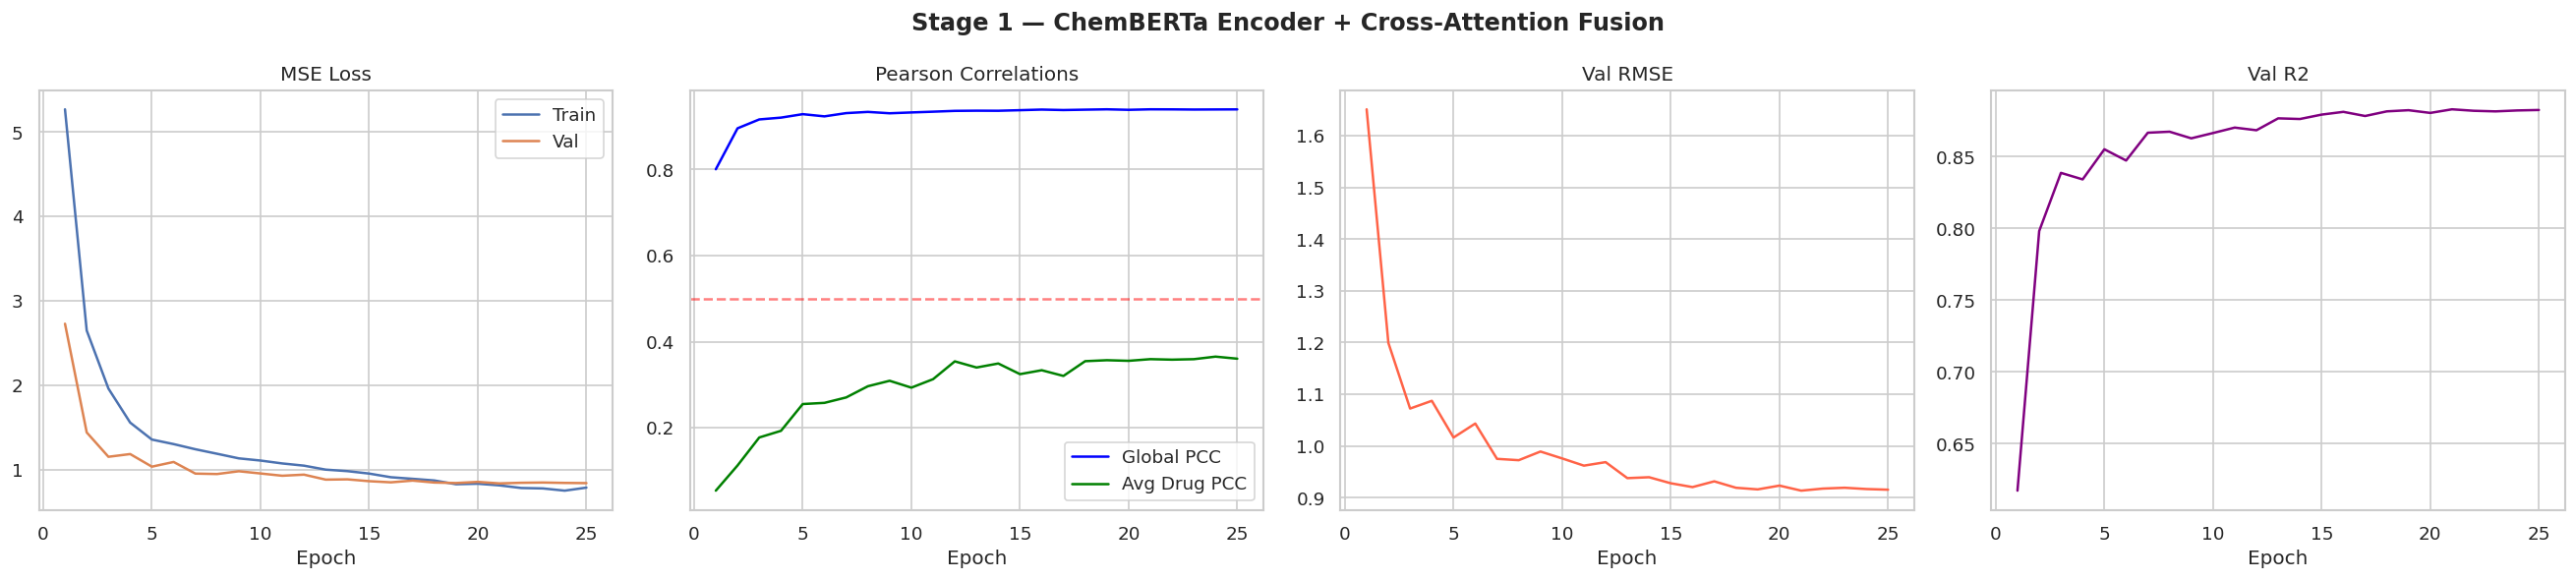

In [8]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 8 — STAGE 1 TRAINING
#  Head + cross-attention + ChemBERTa upper layers (backbone frozen).
# ═══════════════════════════════════════════════════════════════════════
section(f'8. STAGE 1 TRAINING ({CONFIG["stage1_epochs"]} epochs)')

m = get_module(model)
trainable_s1 = [
    {'params': m.drug_encoder.parameters(),    'lr': CONFIG['stage1_lr'] * 0.1},
    {'params': m.fusion.parameters(),          'lr': CONFIG['stage1_lr']},
    {'params': m.regression_head.parameters(), 'lr': CONFIG['stage1_lr']},
]
opt_s1 = optim.AdamW(trainable_s1, weight_decay=CONFIG['stage1_wd'])

steps_per_epoch = math.ceil(len(train_loader) / CONFIG['grad_accum'])
total_steps_s1  = steps_per_epoch * CONFIG['stage1_epochs']

sched_s1 = optim.lr_scheduler.OneCycleLR(
    opt_s1,
    max_lr=[CONFIG['stage1_lr'] * 0.1, CONFIG['stage1_lr'], CONFIG['stage1_lr']],
    total_steps=total_steps_s1, pct_start=CONFIG['warmup_frac'],
    anneal_strategy='cos', div_factor=10.0, final_div_factor=100.0)
scaler_s1  = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])
best_s1    = -np.inf; patience_s1 = 0
hist_s1    = {k: [] for k in ['train_loss','val_loss','val_pcc','val_drug_pcc','val_rmse','val_r2']}

print(f'Steps/epoch: {steps_per_epoch} | Total: {total_steps_s1}')
print(f'Trainable:   {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print()

for epoch in range(1, CONFIG['stage1_epochs'] + 1):
    t0 = time.time()
    tr_loss, tr_p, tr_t, tr_d = run_epoch(
        model, train_loader, opt_s1, scaler_s1, True, sched_s1, CONFIG['grad_accum'])
    vl_loss, vl_p, vl_t, vl_d = run_epoch(
        model, val_loader, opt_s1, scaler_s1, False)
    vm = compute_metrics(vl_p, vl_t, vl_d, id_to_drug)
    for k, v in zip(['train_loss','val_loss','val_pcc','val_drug_pcc','val_rmse','val_r2'],
                    [tr_loss, vl_loss, vm['pearson'], vm['avg_drug_pearson'], vm['rmse'], vm['r2']]):
        hist_s1[k].append(v)
    print(f'[S1 {epoch:02d}/{CONFIG["stage1_epochs"]}]  '
          f'TrLoss={tr_loss:.4f}  VlLoss={vl_loss:.4f}  '
          f'PCC={vm["pearson"]:.4f}  SCC={vm["spearman"]:.4f}  '
          f'RMSE={vm["rmse"]:.4f}  R2={vm["r2"]:.4f}  '
          f'DrugPCC={vm["avg_drug_pearson"]:.4f}  {time.time()-t0:.0f}s')
    # if vm['avg_drug_pearson'] > best_s1:
    #     best_s1 = vm['avg_drug_pearson']; patience_s1 = 0
    #     torch.save(get_module(model).state_dict(), CONFIG['checkpoint_ft'])
    #     print(f'  Best saved (DrugPCC={best_s1:.4f})')
    if vm['pearson'] > best_s1:
        best_s1 = vm['pearson']; patience_s1 = 0
        torch.save(get_module(model).state_dict(), CONFIG['checkpoint_ft'])
        print(f'  ✓ Best saved  GlobalPCC={best_s1:.4f}  DrugPCC={vm["avg_drug_pearson"]:.4f}')
    else:
        patience_s1 += 1
        if patience_s1 >= CONFIG['stage1_patience']:
            print(f'  Early stopping at epoch {epoch}'); break

print(f'\nStage 1 complete. Best GlobalPCC = {best_s1:.4f}')

E = range(1, len(hist_s1['train_loss']) + 1)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Stage 1 — ChemBERTa Encoder + Cross-Attention Fusion', fontweight='bold')
axes[0].plot(E, hist_s1['train_loss'], label='Train')
axes[0].plot(E, hist_s1['val_loss'],   label='Val'); axes[0].set_title('MSE Loss'); axes[0].legend()
axes[1].plot(E, hist_s1['val_pcc'],      label='Global PCC',   color='blue')
axes[1].plot(E, hist_s1['val_drug_pcc'], label='Avg Drug PCC', color='green')
axes[1].axhline(0.5, color='red', ls='--', alpha=0.5)
axes[1].set_title('Pearson Correlations'); axes[1].legend()
axes[2].plot(E, hist_s1['val_rmse'], color='tomato'); axes[2].set_title('Val RMSE')
axes[3].plot(E, hist_s1['val_r2'],   color='purple'); axes[3].set_title('Val R2')
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}stage1_curves.png', dpi=150); plt.show()



══════════════════════════════════════════════════════════════════════
  9. STAGE 2 TRAINING (30 epochs)
══════════════════════════════════════════════════════════════════════
Trainable modules (Stage 2):
  backbone.cross_layers          TRAINABLE 28391424
  backbone.fusion                TRAINABLE 6148
  drug_encoder                   TRAINABLE 296448
  fusion (drug-patient)          TRAINABLE 1825920
  regression_head                TRAINABLE 148865

Total trainable Stage 2: 30,668,805

[S2 01/30]  TrLoss=0.8158  VlLoss=0.8222  PCC=0.9406  SCC=0.8954  RMSE=0.9067  R2=0.8846  DrugPCC=0.3638  88s
  ✓ Best saved  GlobalPCC=0.9406  DrugPCC=0.3638
[S2 02/30]  TrLoss=0.8103  VlLoss=0.8349  PCC=0.9398  SCC=0.8930  RMSE=0.9137  R2=0.8828  DrugPCC=0.3642  88s
[S2 03/30]  TrLoss=0.8123  VlLoss=0.8299  PCC=0.9402  SCC=0.8950  RMSE=0.9110  R2=0.8835  DrugPCC=0.3586  88s
[S2 04/30]  TrLoss=0.8238  VlLoss=0.8289  PCC=0.9402  SCC=0.8957  RMSE=0.9105  R2=0.8836  DrugPCC=0.3741  89s
[S2 05/30]  TrLo

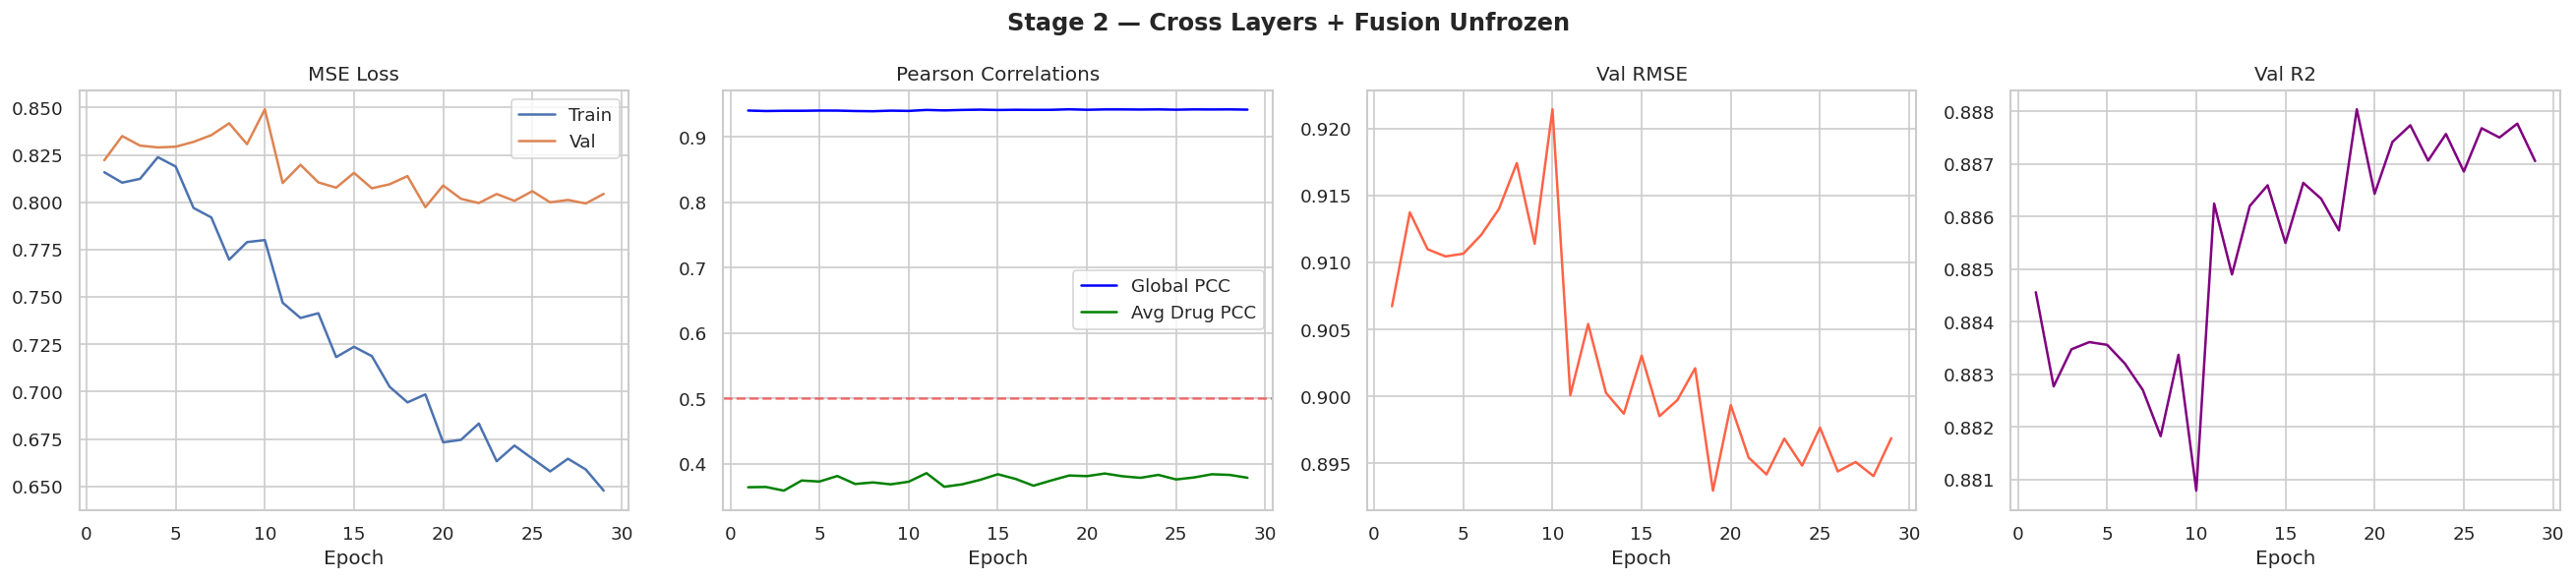

In [9]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 9 — STAGE 2 TRAINING
#  Unfreeze backbone cross_layers + fusion; differential LRs.
# ═══════════════════════════════════════════════════════════════════════
section(f'9. STAGE 2 TRAINING ({CONFIG["stage2_epochs"]} epochs)')

get_module(model).load_state_dict(torch.load(CONFIG['checkpoint_ft'], map_location=DEVICE))

bm = get_module(model).backbone
for p in bm.cross_layers.parameters(): p.requires_grad = True
for p in bm.fusion.parameters():       p.requires_grad = True

print('Trainable modules (Stage 2):')
modules_s2 = {
    'backbone.cross_layers': bm.cross_layers,
    'backbone.fusion':       bm.fusion,
    'drug_encoder':          get_module(model).drug_encoder,
    'fusion (drug-patient)': get_module(model).fusion,
    'regression_head':       get_module(model).regression_head,
}
for name, mod in modules_s2.items():
    n_tr = sum(p.numel() for p in mod.parameters() if p.requires_grad)
    print(f'  {name:<30} {"TRAINABLE " + str(n_tr) if n_tr else "FROZEN"}')

m = get_module(model)
opt_s2 = optim.AdamW([
    {'params': m.regression_head.parameters(),       'lr': CONFIG['stage2_lr_head']},
    {'params': m.fusion.parameters(),                'lr': CONFIG['stage2_lr_head']},
    {'params': m.backbone.cross_layers.parameters(), 'lr': CONFIG['stage2_lr_cross']},
    {'params': m.backbone.fusion.parameters(),       'lr': CONFIG['stage2_lr_cross']},
    {'params': [p for p in m.drug_encoder.encoder.parameters() if p.requires_grad],
                                                      'lr': CONFIG['stage2_lr_cbert']},
    {'params': m.drug_encoder.proj.parameters(),     'lr': CONFIG['stage2_lr_head']},
], weight_decay=CONFIG['stage2_wd'])

total_steps_s2 = math.ceil(len(train_loader) / CONFIG['grad_accum']) * CONFIG['stage2_epochs']
sched_s2 = optim.lr_scheduler.OneCycleLR(
    opt_s2,
    max_lr=[CONFIG['stage2_lr_head'], CONFIG['stage2_lr_head'],
            CONFIG['stage2_lr_cross'], CONFIG['stage2_lr_cross'],
            CONFIG['stage2_lr_cbert'], CONFIG['stage2_lr_head']],
    total_steps=total_steps_s2, pct_start=CONFIG['warmup_frac'],
    anneal_strategy='cos', div_factor=10.0, final_div_factor=100.0)
scaler_s2  = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])
best_s2    = -np.inf; patience_s2 = 0
hist_s2    = {k: [] for k in ['train_loss','val_loss','val_pcc','val_drug_pcc','val_rmse','val_r2']}

print(f'\nTotal trainable Stage 2: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print()

for epoch in range(1, CONFIG['stage2_epochs'] + 1):
    t0 = time.time()
    tr_loss, tr_p, tr_t, tr_d = run_epoch(
        model, train_loader, opt_s2, scaler_s2, True, sched_s2, CONFIG['grad_accum'])
    vl_loss, vl_p, vl_t, vl_d = run_epoch(
        model, val_loader, opt_s2, scaler_s2, False)
    vm = compute_metrics(vl_p, vl_t, vl_d, id_to_drug)
    for k, v in zip(['train_loss','val_loss','val_pcc','val_drug_pcc','val_rmse','val_r2'],
                    [tr_loss, vl_loss, vm['pearson'], vm['avg_drug_pearson'], vm['rmse'], vm['r2']]):
        hist_s2[k].append(v)
    print(f'[S2 {epoch:02d}/{CONFIG["stage2_epochs"]}]  '
          f'TrLoss={tr_loss:.4f}  VlLoss={vl_loss:.4f}  '
          f'PCC={vm["pearson"]:.4f}  SCC={vm["spearman"]:.4f}  '
          f'RMSE={vm["rmse"]:.4f}  R2={vm["r2"]:.4f}  '
          f'DrugPCC={vm["avg_drug_pearson"]:.4f}  {time.time()-t0:.0f}s')
    if vm['pearson'] > best_s2:
        best_s2 = vm['pearson']; patience_s2 = 0
        torch.save(get_module(model).state_dict(), CONFIG['checkpoint_ft'])
        print(f'  ✓ Best saved  GlobalPCC={best_s2:.4f}  DrugPCC={vm["avg_drug_pearson"]:.4f}')
    else:
        patience_s2 += 1
        if patience_s2 >= CONFIG['stage2_patience']:
            print(f'  Early stopping at epoch {epoch}'); break

print(f'\nStage 2 complete. Best AvgDrugPCC = {best_s2:.4f}')

E = range(1, len(hist_s2['train_loss']) + 1)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Stage 2 — Cross Layers + Fusion Unfrozen', fontweight='bold')
axes[0].plot(E, hist_s2['train_loss'], label='Train')
axes[0].plot(E, hist_s2['val_loss'],   label='Val'); axes[0].set_title('MSE Loss'); axes[0].legend()
axes[1].plot(E, hist_s2['val_pcc'],      label='Global PCC',   color='blue')
axes[1].plot(E, hist_s2['val_drug_pcc'], label='Avg Drug PCC', color='green')
axes[1].axhline(0.5, color='red', ls='--', alpha=0.5)
axes[1].set_title('Pearson Correlations'); axes[1].legend()
axes[2].plot(E, hist_s2['val_rmse'], color='tomato'); axes[2].set_title('Val RMSE')
axes[3].plot(E, hist_s2['val_r2'],   color='purple'); axes[3].set_title('Val R2')
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}stage2_curves.png', dpi=150); plt.show()


In [10]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 10 — EVALUATION ON ALL THREE TEST SPLITS
# ═══════════════════════════════════════════════════════════════════════
section('10. EVALUATION ON ALL THREE TEST SPLITS')

get_module(model).load_state_dict(torch.load(CONFIG['checkpoint_ft'], map_location=DEVICE))
model.eval(); print('Best checkpoint loaded.')

def evaluate_split(loader, split_name):
    _, preds, targets, drug_ids = run_epoch(model, loader, None, None, is_train=False)
    m = compute_metrics(preds, targets, drug_ids, id_to_drug)
    print(f'\n{"="*65}')
    print(f'  {split_name}')
    print(f'{"="*65}')
    print(f'  Pearson PCC:         {m["pearson"]:.4f} <- PRIMARY')
    print(f'  Spearman SCC:        {m["spearman"]:.4f}')
    print(f'  RMSE:                {m["rmse"]:.4f}')
    print(f'  R2:                  {m["r2"]:.4f}')
    print(f'  Avg Per-Drug PCC:    {m["avg_drug_pearson"]:.4f}')
    print(f'  Drugs eval (>=5):    {len(m["per_drug"])}')
    return m, preds, targets, drug_ids

te_warm, te_p_w, te_t_w, te_d_w = evaluate_split(test_loader,      'WARM-START TEST')
te_cell, te_p_c, te_t_c, te_d_c = evaluate_split(cell_cold_loader, 'CELL-COLD-START TEST')
te_drug, te_p_d, te_t_d, te_d_d = evaluate_split(drug_cold_loader, 'DRUG-COLD-START TEST')

print(f'\n{"="*75}')
print('  SUMMARY')
print(f'{"="*75}')
print(f'  {"Split":<22} {"PCC":>8} {"SCC":>8} {"RMSE":>8} {"R2":>8} {"DrugPCC":>10}')
print(f'  {"-"*73}')
for label, m in [('Warm-Start', te_warm), ('Cell-Cold', te_cell), ('Drug-Cold', te_drug)]:
    print(f'  {label:<22} {m["pearson"]:>8.4f} {m["spearman"]:>8.4f} '
          f'{m["rmse"]:>8.4f} {m["r2"]:>8.4f} {m["avg_drug_pearson"]:>10.4f}')
print(f'{"="*75}')
print('\n  SOTA: DTLCDR Warm=0.949 | Cell-Cold=0.867 | Drug-Cold=0.621')
print('        PASO Cell-Cold=0.887')



══════════════════════════════════════════════════════════════════════
  10. EVALUATION ON ALL THREE TEST SPLITS
══════════════════════════════════════════════════════════════════════
Best checkpoint loaded.

  WARM-START TEST
  Pearson PCC:         0.9276 <- PRIMARY
  Spearman SCC:        0.8966
  RMSE:                0.9701
  R2:                  0.8577
  Avg Per-Drug PCC:    0.3330
  Drugs eval (>=5):    54

  CELL-COLD-START TEST
  Pearson PCC:         0.9555 <- PRIMARY
  Spearman SCC:        0.9247
  RMSE:                0.7810
  R2:                  0.9120
  Avg Per-Drug PCC:    0.5731
  Drugs eval (>=5):    58

  DRUG-COLD-START TEST
  Pearson PCC:         0.8658 <- PRIMARY
  Spearman SCC:        0.7644
  RMSE:                0.7581
  R2:                  0.7484
  Avg Per-Drug PCC:    0.5912
  Drugs eval (>=5):    8

  SUMMARY
  Split                       PCC      SCC     RMSE       R2    DrugPCC
  -------------------------------------------------------------------------
  War


══════════════════════════════════════════════════════════════════════
  11. VISUALISATIONS
══════════════════════════════════════════════════════════════════════


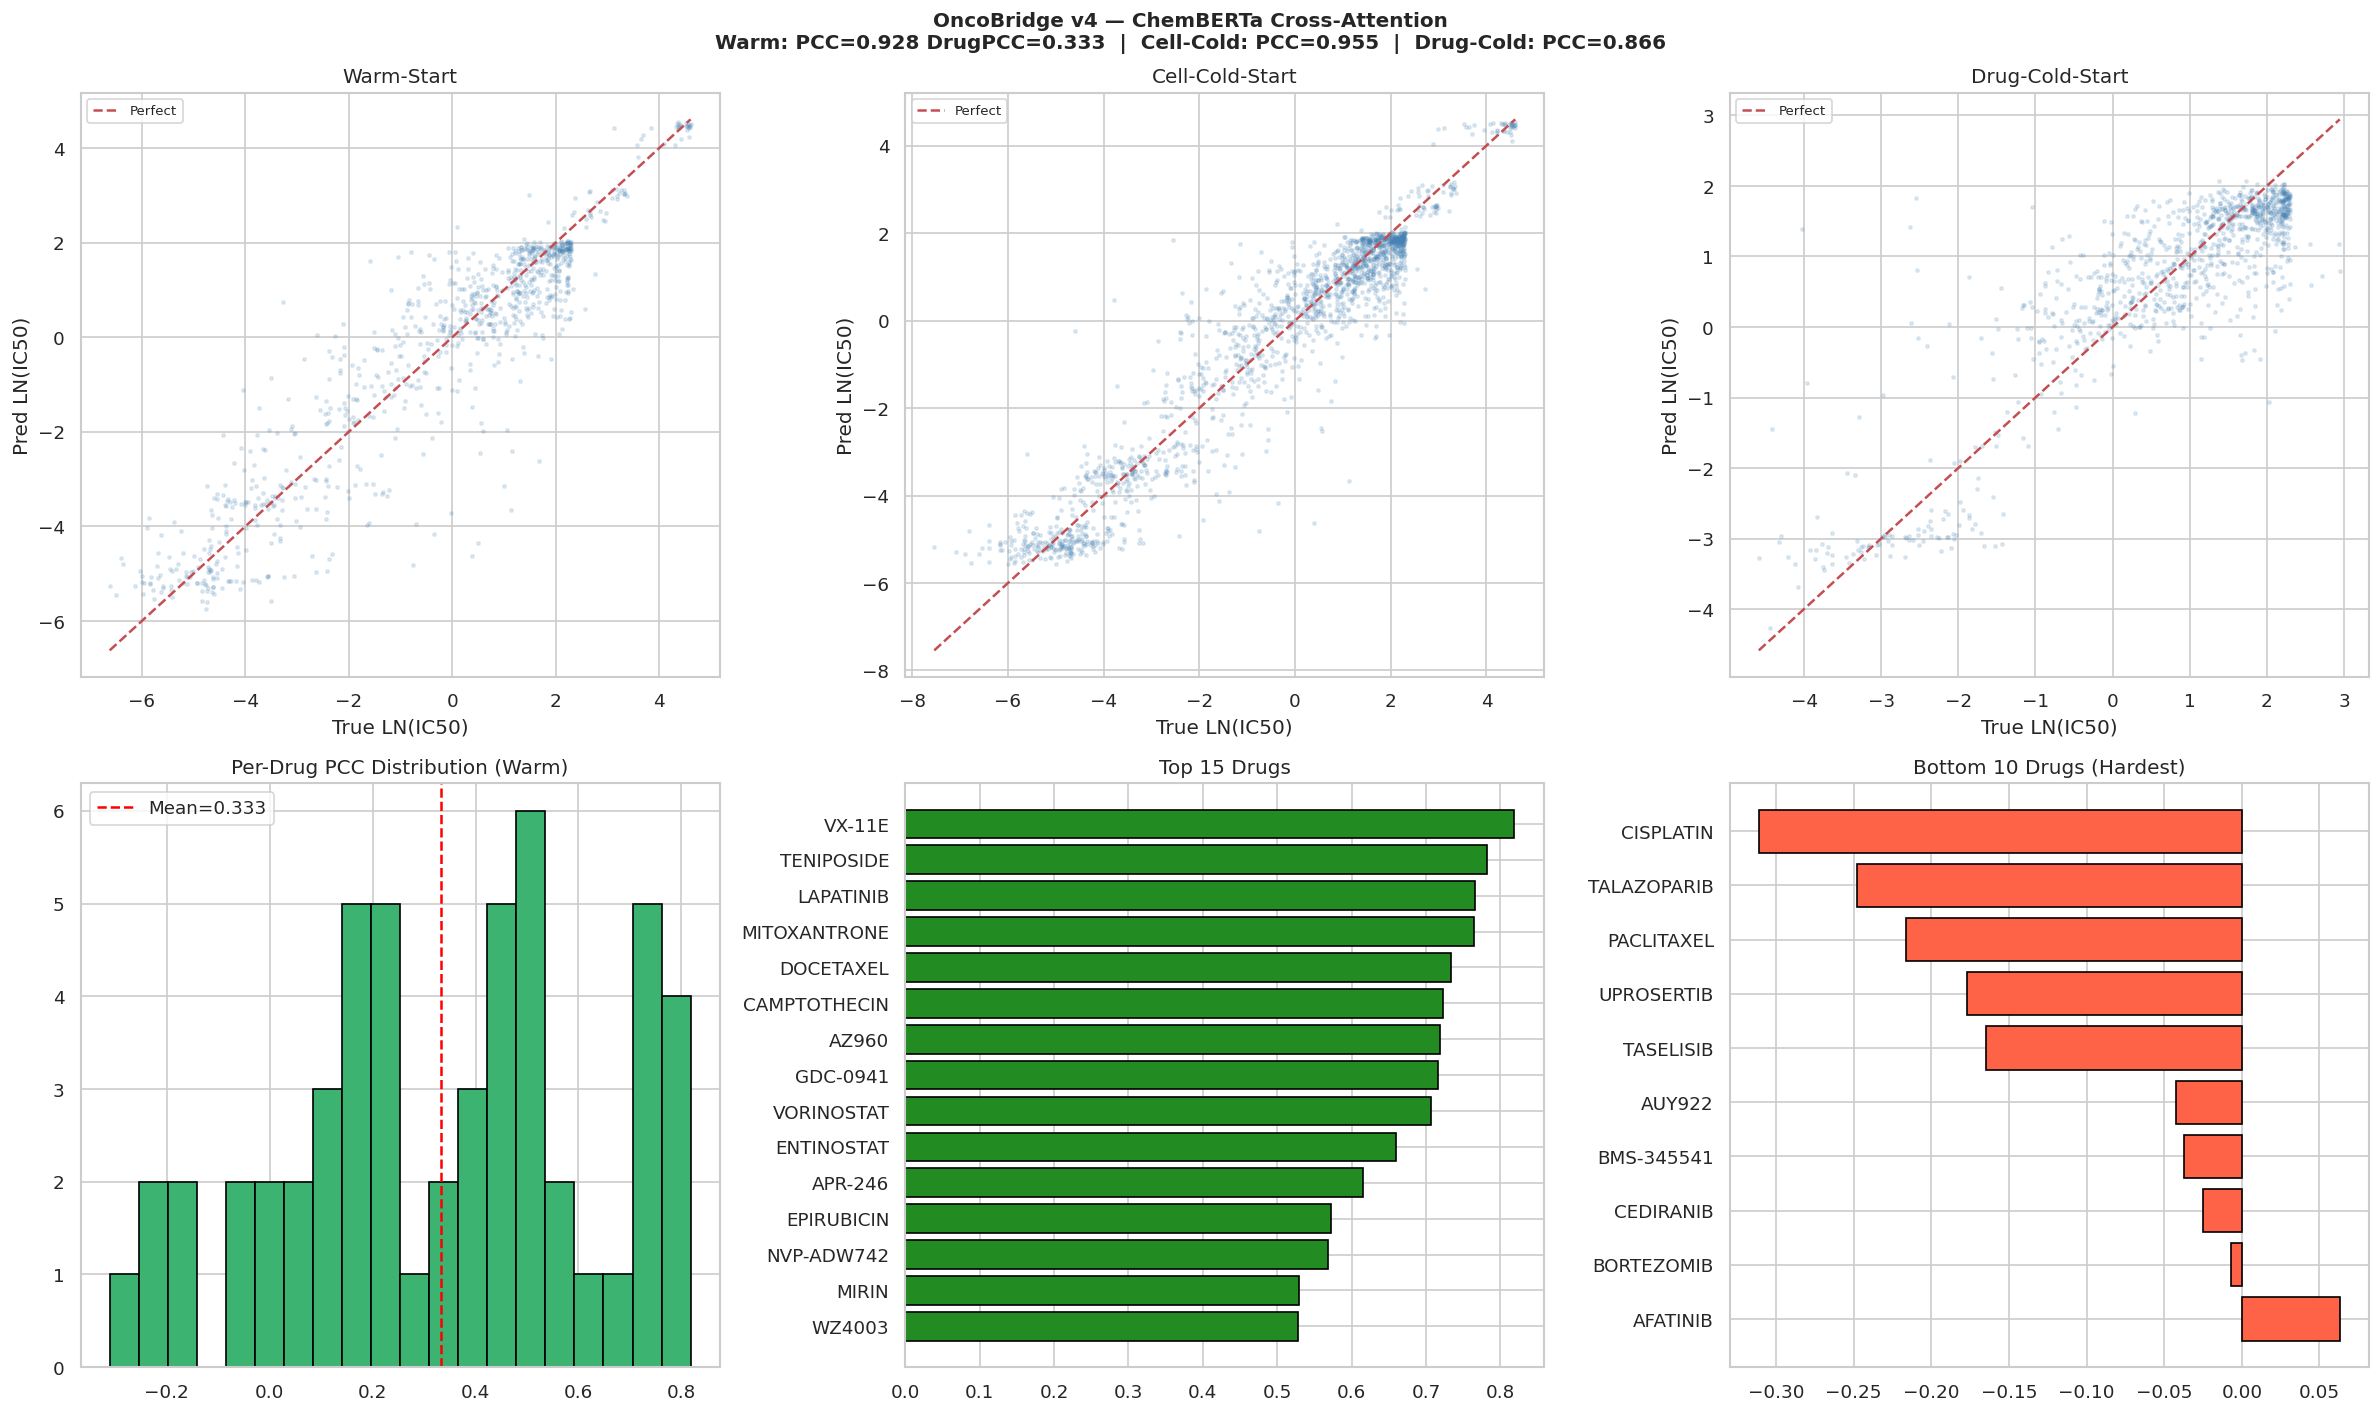


Top 20 drugs (Warm-Start):
              Pearson  N_Samples
VX-11E         0.8180        5.0
TENIPOSIDE     0.7823       21.0
LAPATINIB      0.7656        8.0
MITOXANTRONE   0.7639       13.0
DOCETAXEL      0.7330       18.0
CAMPTOTHECIN   0.7232       16.0
AZ960          0.7187        9.0
GDC-0941       0.7161        8.0
VORINOSTAT     0.7069       25.0
ENTINOSTAT     0.6593       15.0
APR-246        0.6148       20.0
EPIRUBICIN     0.5718       27.0
NVP-ADW742     0.5681       16.0
MIRIN          0.5289       29.0
WZ4003         0.5282        8.0
CYTARABINE     0.5209        6.0
ABT-737        0.5201       17.0
SORAFENIB      0.5170       17.0
AZD6738        0.5129       17.0
OBATOCLAX      0.4755       25.0

Bottom 10 drugs:
             Pearson  N_Samples
CISPLATIN    -0.3111        8.0
TALAZOPARIB  -0.2481        7.0
PACLITAXEL   -0.2163       12.0
UPROSERTIB   -0.1771       13.0
TASELISIB    -0.1646        6.0
AUY922       -0.0422       16.0
BMS-345541   -0.0372        8.0
CEDIR

In [11]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 11 — VISUALISATIONS
# ═══════════════════════════════════════════════════════════════════════
section('11. VISUALISATIONS')

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    f'OncoBridge v4 — ChemBERTa Cross-Attention\n'
    f'Warm: PCC={te_warm["pearson"]:.3f} DrugPCC={te_warm["avg_drug_pearson"]:.3f}  |  '
    f'Cell-Cold: PCC={te_cell["pearson"]:.3f}  |  Drug-Cold: PCC={te_drug["pearson"]:.3f}',
    fontweight='bold', fontsize=12)

def scatter_plot(ax, true, pred, title):
    ax.scatter(true, pred, alpha=0.15, s=4, c='steelblue', rasterized=True)
    mn = min(true.min(), pred.min()); mx = max(true.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect')
    ax.set_xlabel('True LN(IC50)'); ax.set_ylabel('Pred LN(IC50)')
    ax.set_title(title); ax.legend(fontsize=8)

scatter_plot(axes[0,0], te_t_w, te_p_w, 'Warm-Start')
scatter_plot(axes[0,1], te_t_c, te_p_c, 'Cell-Cold-Start')
scatter_plot(axes[0,2], te_t_d, te_p_d, 'Drug-Cold-Start')

drug_df_w = pd.DataFrame(te_warm['per_drug']).T
drug_df_w.columns = ['Pearson', 'N_Samples']
axes[1,0].hist(drug_df_w['Pearson'], bins=20, color='mediumseagreen', edgecolor='black')
axes[1,0].axvline(drug_df_w['Pearson'].mean(), color='red', ls='--',
                   label=f'Mean={drug_df_w["Pearson"].mean():.3f}')
axes[1,0].set_title('Per-Drug PCC Distribution (Warm)'); axes[1,0].legend()

top15    = drug_df_w['Pearson'].nlargest(15)
bottom10 = drug_df_w['Pearson'].nsmallest(10)
axes[1,1].barh(top15.index, top15.values, color='forestgreen', edgecolor='black')
axes[1,1].set_title('Top 15 Drugs'); axes[1,1].invert_yaxis()
axes[1,2].barh(bottom10.index, bottom10.values, color='tomato', edgecolor='black')
axes[1,2].set_title('Bottom 10 Drugs (Hardest)'); axes[1,2].invert_yaxis()

plt.tight_layout(); plt.savefig(f'{OUT_DIR}evaluation_all_splits.png', dpi=150); plt.show()

print('\nTop 20 drugs (Warm-Start):')
print(drug_df_w.sort_values('Pearson', ascending=False).head(20).round(4).to_string())
print('\nBottom 10 drugs:')
print(drug_df_w.sort_values('Pearson').head(10).round(4).to_string())
drug_df_w.to_csv(f'{OUT_DIR}per_drug_metrics_warm.csv')



══════════════════════════════════════════════════════════════════════
  12. ABLATION STUDY
══════════════════════════════════════════════════════════════════════
Running ablation on warm-start test...
  Setting                                     DrugPCC  GlobalPCC     RMSE       R2
  ------------------------------------------------------------------------------
  All 4 modalities (full model)                0.3330     0.9276   0.9701   0.8577
  No mRNA                                      0.0835     0.9133   1.0607   0.8298
  No CNV                                       0.2743     0.9238   0.9917   0.8512
  No Mutation                                  0.3264     0.9245   0.9803   0.8546
  No Methylation                               0.2371     0.9222   0.9996   0.8489
  mRNA only                                    0.2789     0.9167   1.0290   0.8399
  mRNA + CNV only                              0.2608     0.9150   1.0385   0.8369
  mRNA + Mutation only                         0.224

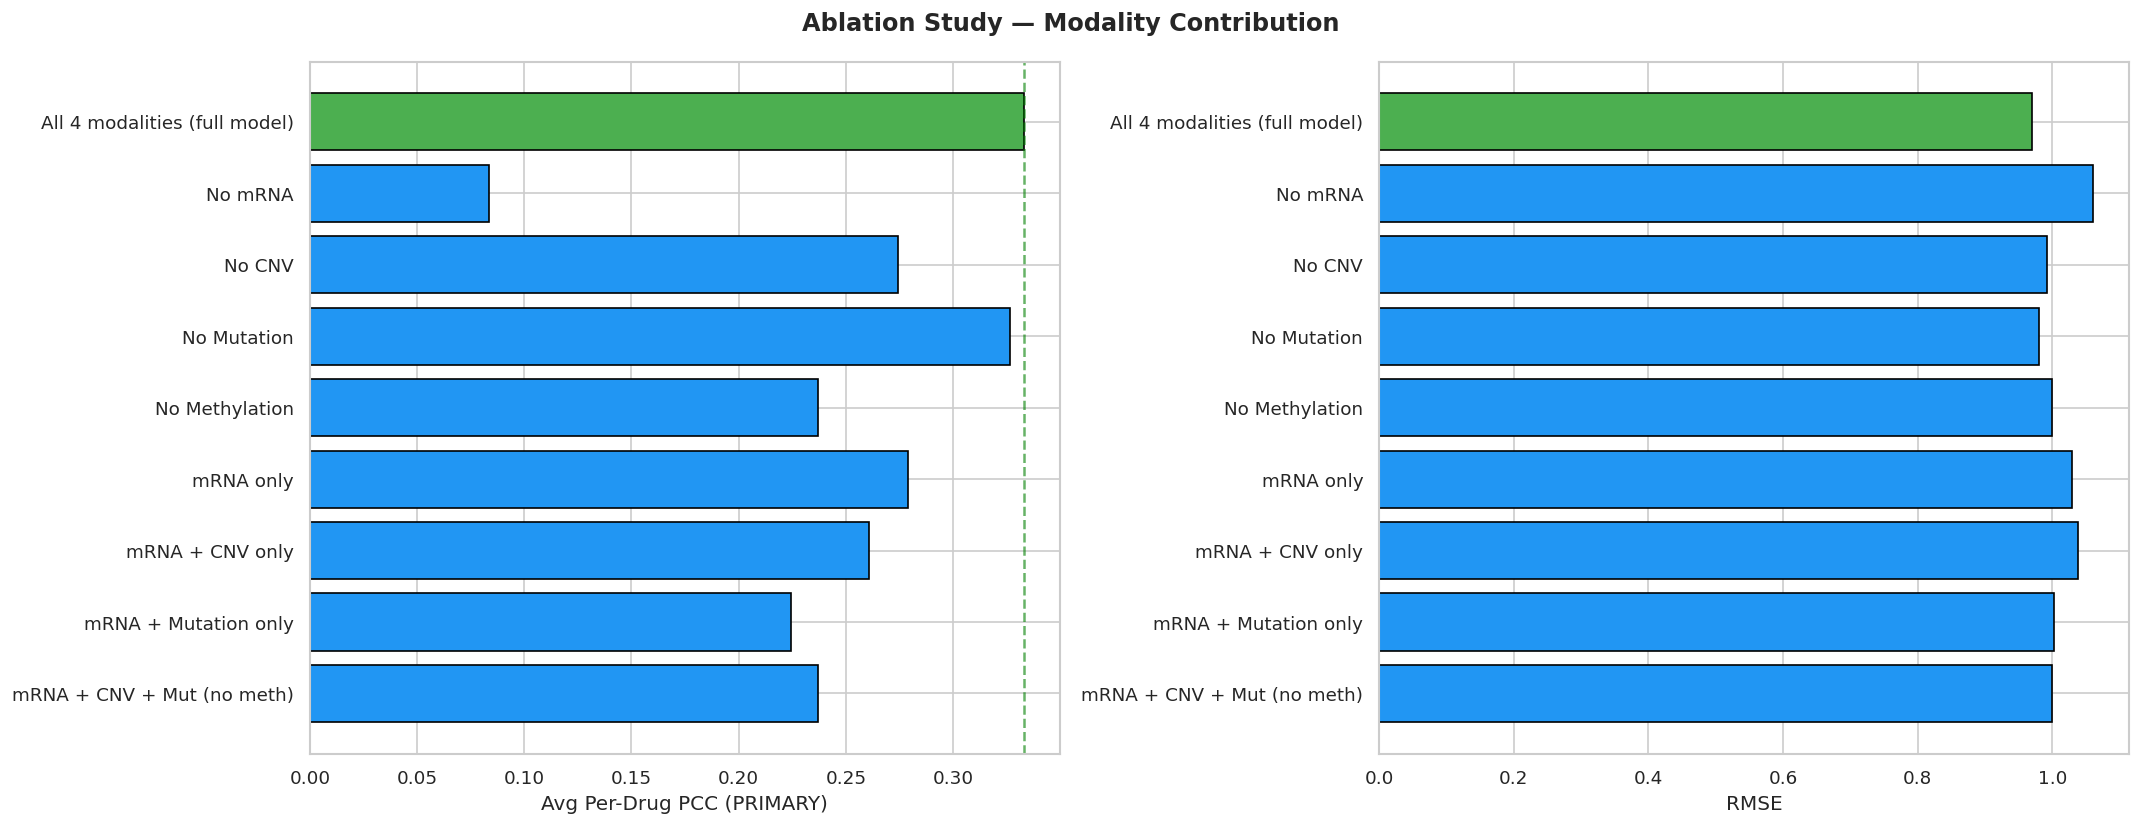

Saved: ablation_results.csv


In [12]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 12 — ABLATION STUDY
# ═══════════════════════════════════════════════════════════════════════
section('12. ABLATION STUDY')

def ablation_eval(model, loader, zero_mods=None):
    model.eval(); all_p, all_t, all_d = [], [], []
    with torch.no_grad():
        for b in loader:
            mrna = b['mrna'].to(DEVICE); cnv  = b['cnv'].to(DEVICE)
            mut  = b['mut'].to(DEVICE);  meth = b['meth'].to(DEVICE)
            ids  = b['input_ids'].to(DEVICE); mask = b['attention_mask'].to(DEVICE)
            ic50 = b['ic50'].to(DEVICE)
            if zero_mods:
                if 'mrna' in zero_mods: mrna = torch.zeros_like(mrna)
                if 'cnv'  in zero_mods: cnv  = torch.zeros_like(cnv)
                if 'mut'  in zero_mods: mut  = torch.zeros_like(mut)
                if 'meth' in zero_mods: meth = torch.zeros_like(meth)
            pred = model(mrna, cnv, mut, meth, ids, mask).squeeze(1)
            all_p.append(pred.cpu().numpy()); all_t.append(ic50.cpu().numpy())
            all_d.append(b['drug_idx'].numpy())
    p = np.concatenate(all_p); t = np.concatenate(all_t); d = np.concatenate(all_d)
    m = compute_metrics(p, t, d, id_to_drug)
    return m['avg_drug_pearson'], m['pearson'], m['rmse'], m['r2']

ablation_configs = [
    ('All 4 modalities (full model)',   []),
    ('No mRNA',                         ['mrna']),
    ('No CNV',                          ['cnv']),
    ('No Mutation',                     ['mut']),
    ('No Methylation',                  ['meth']),
    ('mRNA only',                       ['cnv','mut','meth']),
    ('mRNA + CNV only',                 ['mut','meth']),
    ('mRNA + Mutation only',            ['cnv','meth']),
    ('mRNA + CNV + Mut (no meth)',      ['meth']),
]

print('Running ablation on warm-start test...')
print(f'  {"Setting":<40} {"DrugPCC":>10} {"GlobalPCC":>10} {"RMSE":>8} {"R2":>8}')
print(f'  {"-"*78}')

abl_results = []
for name, zero_mods in ablation_configs:
    dp, gp, rmse, r2 = ablation_eval(model, test_loader, zero_mods)
    abl_results.append({'Setting': name, 'AvgDrugPCC': round(dp,4),
                        'GlobalPCC': round(gp,4), 'RMSE': round(rmse,4), 'R2': round(r2,4)})
    print(f'  {name:<40} {dp:>10.4f} {gp:>10.4f} {rmse:>8.4f} {r2:>8.4f}')

abl_df = pd.DataFrame(abl_results)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Ablation Study — Modality Contribution', fontweight='bold')
colors = ['#4CAF50' if i == 0 else '#2196F3' for i in range(len(abl_df))]
axes[0].barh(abl_df['Setting'], abl_df['AvgDrugPCC'], color=colors, edgecolor='black')
axes[0].axvline(abl_df.iloc[0]['AvgDrugPCC'], color='green', ls='--', alpha=0.6)
axes[0].set_xlabel('Avg Per-Drug PCC (PRIMARY)'); axes[0].invert_yaxis()
axes[1].barh(abl_df['Setting'], abl_df['RMSE'], color=colors, edgecolor='black')
axes[1].set_xlabel('RMSE'); axes[1].invert_yaxis()
plt.tight_layout(); plt.savefig(f'{OUT_DIR}ablation_study.png', dpi=150); plt.show()
abl_df.to_csv(f'{OUT_DIR}ablation_results.csv', index=False)
print('Saved: ablation_results.csv')



══════════════════════════════════════════════════════════════════════
  13. BENCHMARK COMPARISON
══════════════════════════════════════════════════════════════════════
           Model Dataset     Split  GlobalPCC  AvgDrugPCC     RMSE       R2                    Notes
Ridge Regression    GDSC      Warm   0.780000         NaN 2.368000      NaN                 Baseline
  DeepCDR (2020)    GDSC      Warm   0.923000         NaN 1.058000      NaN        UGCN drug encoder
 GraphDRP (2022)   GDSC2      Warm   0.939000         NaN      NaN      NaN         GNN drug encoder
  DeepTTA (2022)   GDSC2      Warm   0.937000         NaN      NaN      NaN         Transformer drug
    TGDRP (2022)   GDSC2      Warm   0.890000         NaN      NaN      NaN                 Twin GNN
  DRN-CDR (2024)   GDSC2      Warm   0.794000         NaN 0.924000      NaN                   ResNet
   DTLCDR (2025)   GDSC2      Warm   0.949000         NaN      NaN      NaN                   scBERT
   DTLCDR (2025)   GDS

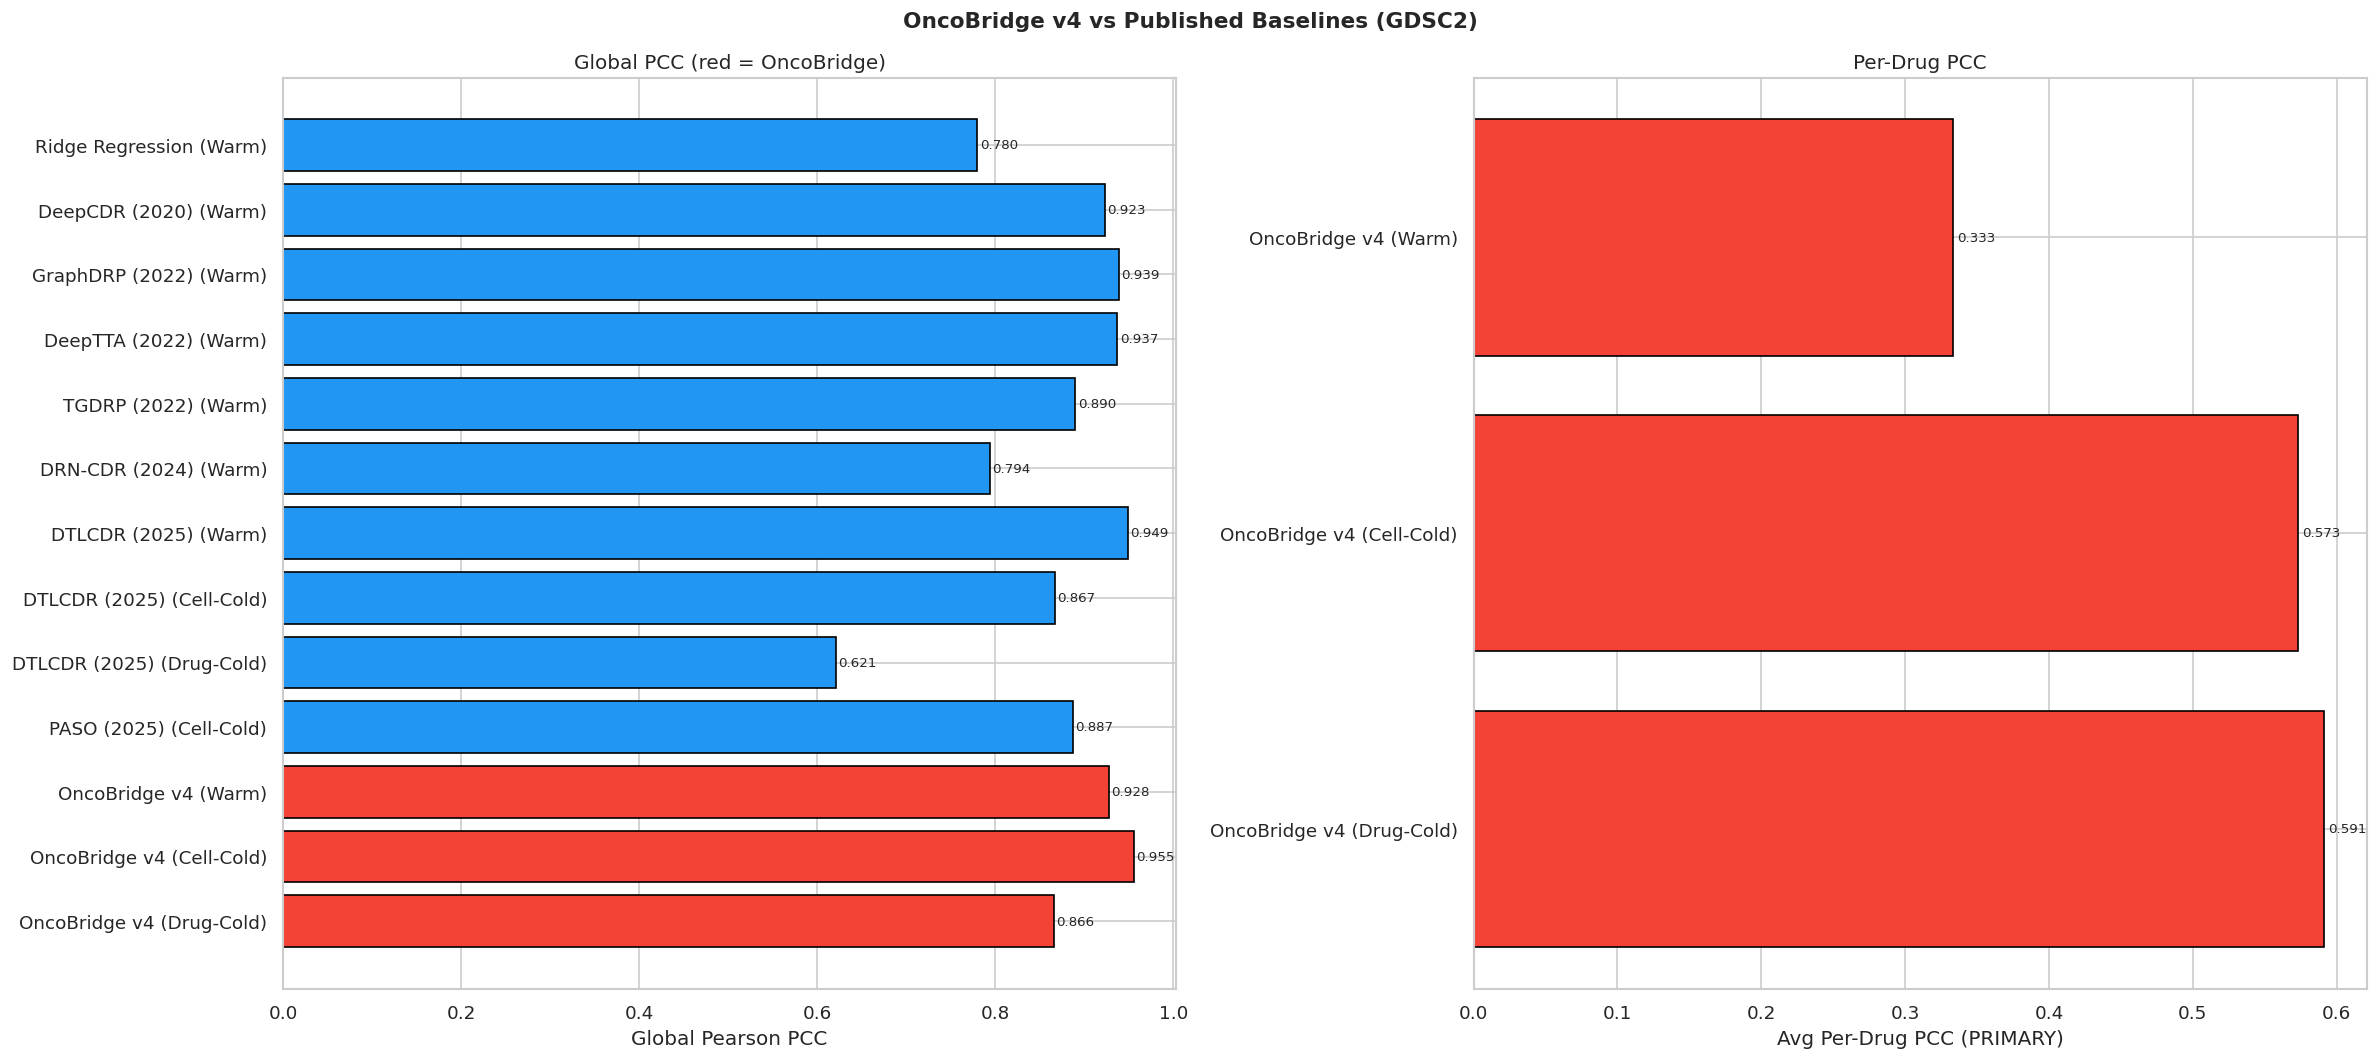


  PIPELINE COMPLETE — OncoBridge v4
  Warm:      PCC=0.9276  DrugPCC=0.3330  RMSE=0.9701
  Cell-Cold: PCC=0.9555  DrugPCC=0.5731
  Drug-Cold: PCC=0.8658  DrugPCC=0.5912
Checkpoint: /kaggle/working/oncobridge_chemberta_v4_best.pt


In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 13 — BENCHMARK COMPARISON
# ═══════════════════════════════════════════════════════════════════════
section('13. BENCHMARK COMPARISON')

benchmarks = [
    ('Ridge Regression', 'GDSC',  'Warm',      0.780, None,  2.368, None, 'Baseline'),
    ('DeepCDR (2020)',   'GDSC',  'Warm',      0.923, None,  1.058, None, 'UGCN drug encoder'),
    ('GraphDRP (2022)',  'GDSC2', 'Warm',      0.939, None,  None,  None, 'GNN drug encoder'),
    ('DeepTTA (2022)',   'GDSC2', 'Warm',      0.937, None,  None,  None, 'Transformer drug'),
    ('TGDRP (2022)',     'GDSC2', 'Warm',      0.890, None,  None,  None, 'Twin GNN'),
    ('DRN-CDR (2024)',   'GDSC2', 'Warm',      0.794, None,  0.924, None, 'ResNet'),
    ('DTLCDR (2025)',    'GDSC2', 'Warm',      0.949, None,  None,  None, 'scBERT'),
    ('DTLCDR (2025)',    'GDSC2', 'Cell-Cold', 0.867, None,  None,  None, 'Unseen cells'),
    ('DTLCDR (2025)',    'GDSC2', 'Drug-Cold', 0.621, None,  None,  None, 'Unseen drugs'),
    ('PASO (2025)',      'GDSC2', 'Cell-Cold', 0.887, None,  None,  None, 'Pathway features'),
    ('OncoBridge v4', 'GDSC2', 'Warm',
     te_warm['pearson'], te_warm['avg_drug_pearson'], te_warm['rmse'], te_warm['r2'],
     'TCGA+ChemBERTa+CrossAttn'),
    ('OncoBridge v4', 'GDSC2', 'Cell-Cold',
     te_cell['pearson'], te_cell['avg_drug_pearson'], te_cell['rmse'], te_cell['r2'],
     'TCGA+ChemBERTa+CrossAttn'),
    ('OncoBridge v4', 'GDSC2', 'Drug-Cold',
     te_drug['pearson'], te_drug['avg_drug_pearson'], te_drug['rmse'], te_drug['r2'],
     'TCGA+ChemBERTa+CrossAttn'),
]
bm_df = pd.DataFrame(benchmarks,
    columns=['Model','Dataset','Split','GlobalPCC','AvgDrugPCC','RMSE','R2','Notes'])
print(bm_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('OncoBridge v4 vs Published Baselines (GDSC2)', fontweight='bold', fontsize=13)

pcc_df = bm_df.dropna(subset=['GlobalPCC'])
colors = ['#F44336' if 'OncoBridge' in m else '#2196F3' for m in pcc_df['Model']]
bars = axes[0].barh(pcc_df['Model']+' ('+pcc_df['Split']+')', pcc_df['GlobalPCC'],
                     color=colors, edgecolor='black')
axes[0].set_xlabel('Global Pearson PCC'); axes[0].set_title('Global PCC (red = OncoBridge)')
axes[0].invert_yaxis()
for bar, v in zip(bars, pcc_df['GlobalPCC']):
    axes[0].text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                  f'{v:.3f}', va='center', fontsize=8)

dpcc_df = bm_df.dropna(subset=['AvgDrugPCC'])
colors2 = ['#F44336' if 'OncoBridge' in m else '#2196F3' for m in dpcc_df['Model']]
bars2 = axes[1].barh(dpcc_df['Model']+' ('+dpcc_df['Split']+')', dpcc_df['AvgDrugPCC'],
                      color=colors2, edgecolor='black')
axes[1].set_xlabel('Avg Per-Drug PCC (PRIMARY)'); axes[1].set_title('Per-Drug PCC')
axes[1].invert_yaxis()
for bar, v in zip(bars2, dpcc_df['AvgDrugPCC']):
    axes[1].text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                  f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout(); plt.savefig(f'{OUT_DIR}benchmark_comparison.png', dpi=150); plt.show()
bm_df.to_csv(f'{OUT_DIR}benchmark_comparison.csv', index=False)

print('\n' + '='*65)
print('  PIPELINE COMPLETE — OncoBridge v4')
print('='*65)
print(f'  Warm:      PCC={te_warm["pearson"]:.4f}  DrugPCC={te_warm["avg_drug_pearson"]:.4f}  RMSE={te_warm["rmse"]:.4f}')
print(f'  Cell-Cold: PCC={te_cell["pearson"]:.4f}  DrugPCC={te_cell["avg_drug_pearson"]:.4f}')
print(f'  Drug-Cold: PCC={te_drug["pearson"]:.4f}  DrugPCC={te_drug["avg_drug_pearson"]:.4f}')
print('='*65)
print('Checkpoint:', CONFIG['checkpoint_ft'])



══════════════════════════════════════════════════════════════════════
  14. DRUG RANKINGS & DELTA-IC50 HEATMAP
══════════════════════════════════════════════════════════════════════
Total unique (cell, drug) pairs for heatmap: 9,343
Predictions attached. IC50 pred range: [-5.74, 4.57]
Cancer type column found: "OncotreePrimaryDisease"
Using top-25 drugs by warm-test per-drug PCC for heatmap axes.


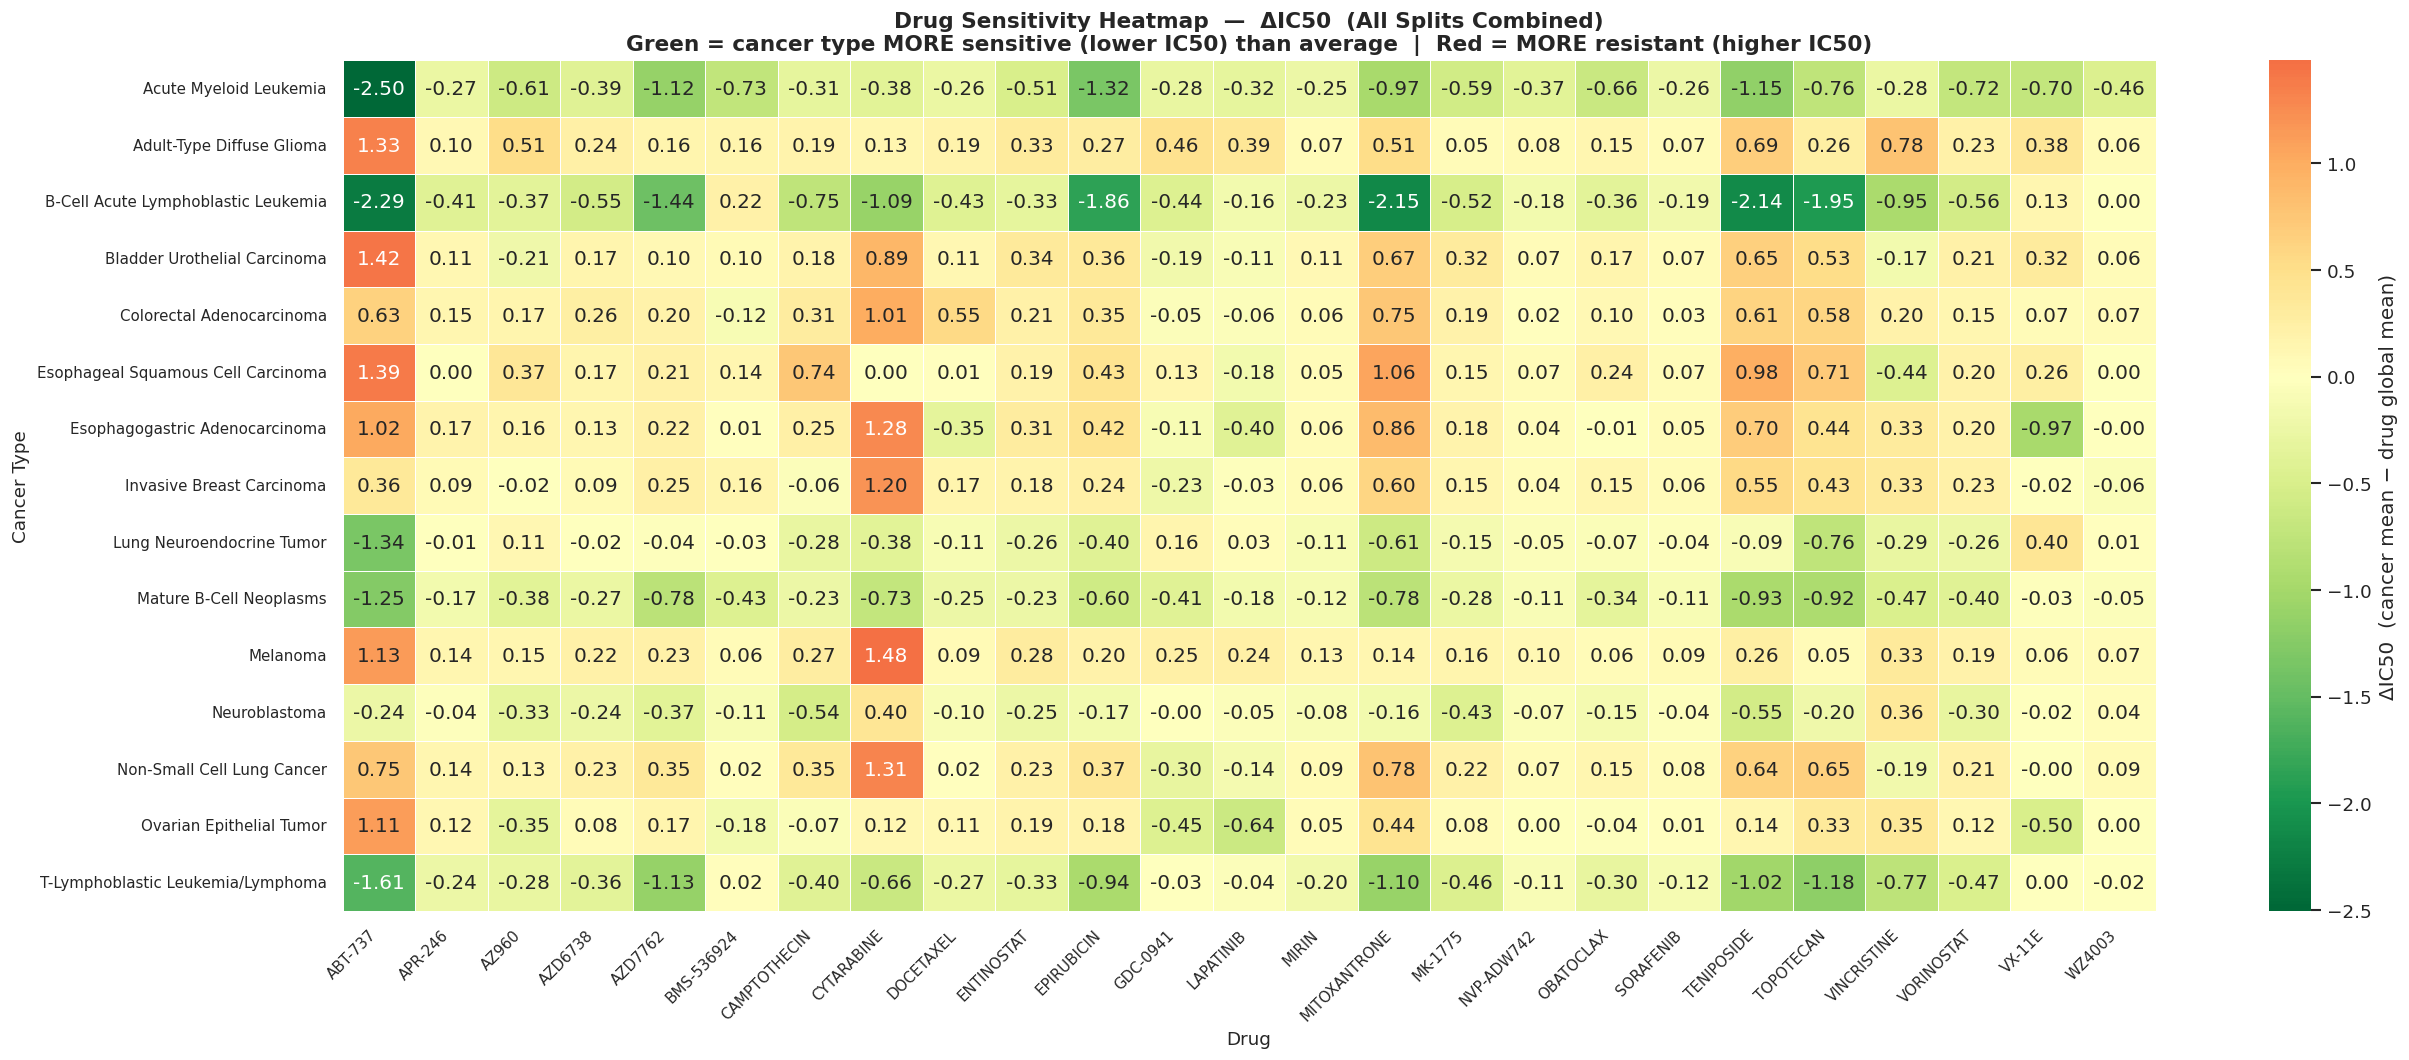

Saved: v4_delta_ic50_heatmap_all_splits.png


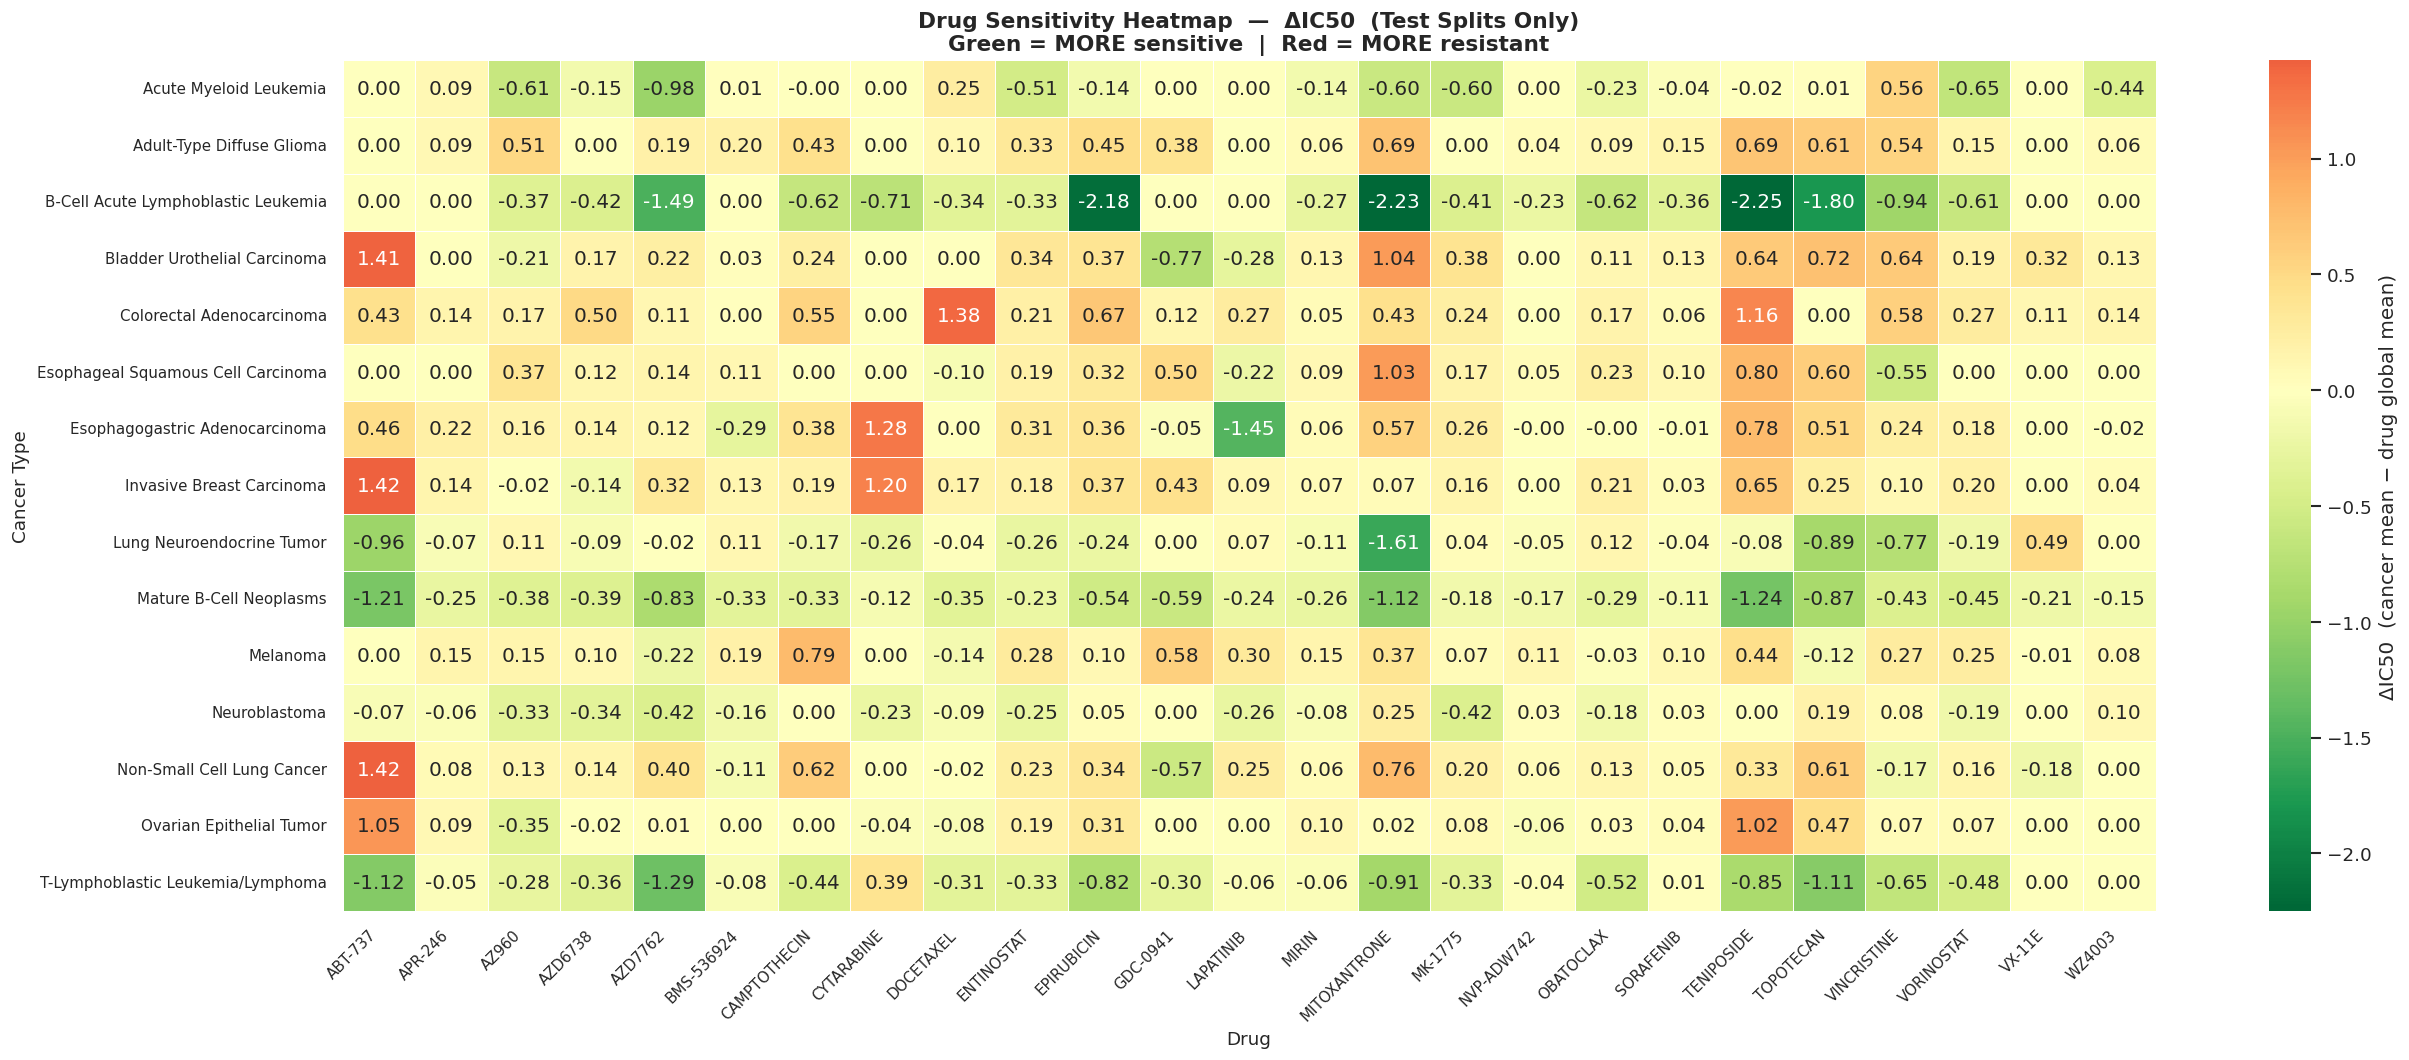

Saved: v4_delta_ic50_heatmap_test_splits.png

Top 5 predicted sensitive drugs per cancer type (lowest predicted IC50):
                                                                             OncotreePrimaryDisease    DRUG_NAME  mean_pred_ic50  mean_true_ic50  std_pred_ic50  n_cell_lines
                                                                             Acute Myeloid Leukemia   PACLITAXEL       -5.509686       -4.980347       0.187699             8
                                                                             Acute Myeloid Leukemia   BORTEZOMIB       -5.445326       -5.034787       0.182927             9
                                                                             Acute Myeloid Leukemia    DOCETAXEL       -5.403465       -4.692358       0.338583            11
                                                                             Acute Myeloid Leukemia  VINORELBINE       -5.311867       -5.425622       0.172809             7
           

In [14]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 14 — DRUG RANKINGS + DELTA-IC50 SENSITIVITY HEATMAP
#  Adapted from v3 → v4: ChemBERTa live inference (no DRUG_EMB_MATRIX)
#  Runs on ALL splits combined for maximum cancer-type coverage.
#  Falls back gracefully if OncotreePrimaryDisease column is missing.
# ═══════════════════════════════════════════════════════════════════════
section('14. DRUG RANKINGS & DELTA-IC50 HEATMAP')

# ── 1. Combine all splits into one deduplicated DataFrame ─────────────
all_recs_raw = pd.concat([
    ic50_warm_tr, ic50_warm_vl, ic50_warm_te,
    ic50_cc_te,   ic50_dc_te
]).drop_duplicates(['ModelID', 'DRUG_NAME']).reset_index(drop=True)

print(f'Total unique (cell, drug) pairs for heatmap: {len(all_recs_raw):,}')

# ── 2. Build DataLoader and run inference ─────────────────────────────
all_ds_hm = DrugResponseDataset(
    all_recs_raw,
    mrna_arr, cnv_arr, mut_arr, meth_arr,
    smiles_map, tokenizer, CONFIG['chemberta_max_len']
)
all_loader_hm = DataLoader(
    all_ds_hm,
    batch_size=CONFIG['batch_size'] * 2,
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
    persistent_workers=(CONFIG['num_workers'] > 0),
    prefetch_factor=2 if CONFIG['num_workers'] > 0 else None,
)

_, hm_preds, hm_targets, hm_dids = run_epoch(
    model, all_loader_hm, None, None, is_train=False
)

assert len(hm_preds) == len(all_recs_raw), \
    f'Prediction count mismatch: {len(hm_preds)} preds vs {len(all_recs_raw)} records'

all_recs_raw['PRED_IC50'] = hm_preds
print(f'Predictions attached. IC50 pred range: [{hm_preds.min():.2f}, {hm_preds.max():.2f}]')

# ── 3. Auto-detect cancer type column ────────────────────────────────
CANCER_COL = None
for candidate in ['OncotreePrimaryDisease', 'cancer_type', 'tissue', 'TissueType', 'Tissue']:
    if candidate in all_recs_raw.columns:
        CANCER_COL = candidate
        print(f'Cancer type column found: "{CANCER_COL}"')
        break

if CANCER_COL is None:
    print('WARNING: No cancer type column found in splits.')
    print(f'Available columns: {all_recs_raw.columns.tolist()}')
    print('Heatmap skipped — drug rankings will still be generated below.')
else:
    # ── 4. Delta-IC50: pred - drug global mean ────────────────────────
    drug_global_mean = all_recs_raw.groupby('DRUG_NAME')['PRED_IC50'].mean()
    all_recs_raw['delta_ic50'] = all_recs_raw.apply(
        lambda r: r['PRED_IC50'] - drug_global_mean[r['DRUG_NAME']], axis=1
    )

    # ── 5. Select top cancers and top drugs ───────────────────────────
    top_cancers = (all_recs_raw[CANCER_COL]
                   .value_counts().head(15).index.tolist())

    # Use top-25 drugs by per-drug PCC from warm-start test evaluation
    # (te_warm computed in Cell 10; falls back to most-common drugs if missing)
    try:
        top_drugs_hm = (pd.DataFrame(te_warm['per_drug']).T
                        .sort_values('pearson', ascending=False)
                        .head(25).index.tolist())
        print(f'Using top-25 drugs by warm-test per-drug PCC for heatmap axes.')
    except Exception:
        top_drugs_hm = (all_recs_raw.groupby('DRUG_NAME')['PRED_IC50']
                        .count().sort_values(ascending=False).head(25).index.tolist())
        print('te_warm per_drug not available; using 25 most-common drugs instead.')

    # ── 6. Pivot and plot ─────────────────────────────────────────────
    pivot = (
        all_recs_raw[
            all_recs_raw[CANCER_COL].isin(top_cancers) &
            all_recs_raw['DRUG_NAME'].isin(top_drugs_hm)
        ]
        .groupby([CANCER_COL, 'DRUG_NAME'])['delta_ic50'].mean()
        .unstack(fill_value=0)
    )

    if pivot.empty:
        print('WARNING: pivot table is empty — check that DRUG_NAME values match '
              'top_drugs_hm. Skipping heatmap plot.')
    else:
        plt.figure(figsize=(22, 9))
        sns.heatmap(
            pivot, cmap='RdYlGn_r', center=0,
            annot=True, fmt='.2f', linewidths=0.3,
            cbar_kws={'label': 'ΔIC50  (cancer mean − drug global mean)'}
        )
        plt.title(
            'Drug Sensitivity Heatmap  —  ΔIC50  (All Splits Combined)\n'
            'Green = cancer type MORE sensitive (lower IC50) than average  |  '
            'Red = MORE resistant (higher IC50)',
            fontsize=13, fontweight='bold'
        )
        plt.xlabel('Drug', fontsize=11)
        plt.ylabel('Cancer Type', fontsize=11)
        plt.xticks(rotation=45, ha='right', fontsize=9)
        plt.yticks(fontsize=9)
        plt.tight_layout()
        plt.savefig(f'{OUT_DIR}v4_delta_ic50_heatmap_all_splits.png', dpi=150)
        plt.show()
        print('Saved: v4_delta_ic50_heatmap_all_splits.png')

    # ── 7. BONUS: Test-only heatmap (warm_te + cc_te + dc_te) ────────
    test_recs = pd.concat([ic50_warm_te, ic50_cc_te, ic50_dc_te]) \
                  .drop_duplicates(['ModelID', 'DRUG_NAME']).reset_index(drop=True)

    # Match predictions back using the indices from all_recs_raw
    test_recs_merged = test_recs.merge(
        all_recs_raw[['ModelID', 'DRUG_NAME', 'PRED_IC50', 'delta_ic50']],
        on=['ModelID', 'DRUG_NAME'], how='left'
    )
    missing_preds = test_recs_merged['PRED_IC50'].isna().sum()
    if missing_preds > 0:
        print(f'Note: {missing_preds} test rows had no matching prediction (will be NaN in heatmap).')

    pivot_test = (
        test_recs_merged[
            test_recs_merged[CANCER_COL].isin(top_cancers) &
            test_recs_merged['DRUG_NAME'].isin(top_drugs_hm)
        ]
        .groupby([CANCER_COL, 'DRUG_NAME'])['delta_ic50'].mean()
        .unstack(fill_value=0)
    )

    if not pivot_test.empty:
        plt.figure(figsize=(22, 9))
        sns.heatmap(
            pivot_test, cmap='RdYlGn_r', center=0,
            annot=True, fmt='.2f', linewidths=0.3,
            cbar_kws={'label': 'ΔIC50  (cancer mean − drug global mean)'}
        )
        plt.title(
            'Drug Sensitivity Heatmap  —  ΔIC50  (Test Splits Only)\n'
            'Green = MORE sensitive  |  Red = MORE resistant',
            fontsize=13, fontweight='bold'
        )
        plt.xlabel('Drug', fontsize=11)
        plt.ylabel('Cancer Type', fontsize=11)
        plt.xticks(rotation=45, ha='right', fontsize=9)
        plt.yticks(fontsize=9)
        plt.tight_layout()
        plt.savefig(f'{OUT_DIR}v4_delta_ic50_heatmap_test_splits.png', dpi=150)
        plt.show()
        print('Saved: v4_delta_ic50_heatmap_test_splits.png')

# ── 8. Drug rankings per cancer type ─────────────────────────────────
if CANCER_COL is not None:
    drug_ranking = (
        all_recs_raw
        .groupby([CANCER_COL, 'DRUG_NAME'])
        .agg(
            mean_pred_ic50 = ('PRED_IC50',    'mean'),
            mean_true_ic50 = ('ic50_value',   'mean'),   # true label, not prediction
            std_pred_ic50  = ('PRED_IC50',    'std'),
            n_cell_lines   = ('ModelID',      'nunique'),
        )
        .reset_index()
    )

    top5_per_cancer = (
        drug_ranking
        .sort_values([CANCER_COL, 'mean_pred_ic50'])      # lower IC50 = more sensitive
        .groupby(CANCER_COL)
        .head(5)
    )

    print('\nTop 5 predicted sensitive drugs per cancer type (lowest predicted IC50):')
    print(top5_per_cancer.to_string(index=False))
    top5_per_cancer.to_csv(f'{OUT_DIR}v4_drug_rankings_per_cancer.csv', index=False)
    print('Saved: v4_drug_rankings_per_cancer.csv')

# ── 9. Save full prediction table ────────────────────────────────────
all_recs_raw.to_csv(f'{OUT_DIR}v4_all_predictions.csv', index=False)
print('Saved: v4_all_predictions.csv')

print('\n' + '='*70)
print('  CELL 14 COMPLETE — Delta-IC50 Heatmap & Drug Rankings')
print('='*70)
print(f'  Total pairs predicted: {len(all_recs_raw):,}')
if CANCER_COL:
    print(f'  Cancer types covered:  {all_recs_raw[CANCER_COL].nunique()}')
    print(f'  Drugs covered:         {all_recs_raw["DRUG_NAME"].nunique()}')
print(f'  Outputs saved to:      {OUT_DIR}')